# PHẦN 2: TRỰC QUAN HÓA & PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

## 1. Bài toán Kinh doanh (Business Problem)

> **Mục tiêu cốt lõi:** Với bối cảnh Datathon 2026 (e-commerce thời trang), **chỉ đuổi theo quy mô doanh thu** là chưa đủ. Doanh nghiệp cần **tăng trưởng có kiểm soát**: đồng bộ nhu cầu theo mùa vụ, cơ cấu danh mục – kênh – địa lý, hiệu quả khuyến mãi, trải nghiệm (trả hàng / giao hàng), tồn kho và chuẩn bị nền tảng cho **dự báo doanh thu**.

Bản phân tích trong notebook này bám theo **4 trục câu hỏi**:

1. **Tăng trưởng & thời vụ:** Doanh thu và biên lợi nhuận gộp biến động thế nào theo ngày, tháng và năm? Có mùa vụ hay điểm mốc rõ rệt không? Song song đó, **lưu lượng web** và **hiệu quả chuyển đổi** (traffic versus đơn hàng) nói lên điều gì về “chất lượng” tăng trưởng?

2. **Động lực doanh thu và biên lợi nhuận:** Danh mục, phân khúc sản phẩm, **khuyến mãi**, kênh đặt hàng (**order source**), **vùng địa lý** và **traffic website** — nhóm nào kéo doanh thu, nhóm nào đang **bào mòn biên** hoặc cần ưu tiên đầu tư logistics / marketing?

3. **Rủi ro hoàn trả, khách hàng và chuỗi cung ứng:** Tỷ lệ trả hàng, nguyên nhân, mối liên hệ với **thời gian giao** và đánh giá; đồng thời **phân khúc RFM** để nhận diện nhóm khách mang giá trị versus nhóm rủi ro. Ở khâu vận hành, **stockout / fill rate** và tồn kho quá mức gây mất doanh thu hay kẹt vốn ra sao?

4. **Hành động ưu tiên:** Tổng hợp insight thành **đề xuất có thể vận hành** (điều chỉnh promo, size guide, phân bổ kho – kênh, dự báo theo lịch, v.v.), thể hiện rõ mức **mô tả → chẩn đoán → gợi ý hành động** theo tiêu chí chấm Phần 2 của đề.

---

## 2. Thiết lập Môi trường & Cấu hình Phân tích

Trước khi đi vào phân tích chi tiết, chúng ta cần thiết lập các thư viện bổ trợ, cấu hình đường dẫn dữ liệu và thiết lập các thông số trực quan hóa (Visual Styles) để đảm bảo tính nhất quán và chuyên nghiệp cho toàn bộ báo cáo.

### 2.1. Khởi tạo Thư viện và Cấu hình Hệ thống

*   **Thư viện**: Sử dụng `pandas`, `numpy` để xử lý dữ liệu và `matplotlib`, `seaborn` để trực quan hóa.

*   **Đường dẫn**: Tự động kiểm tra và thiết lập đường dẫn đến thư mục chứa các tệp tin CSV (`sales.csv`, `orders.csv`, v.v.).

*   **Định dạng**: Cấu hình hiển thị số thực với 2 chữ số thập phân và phân cách hàng ngàn để dễ theo dõi các chỉ số tài chính.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import matplotlib.ticker as mtick

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("dataset")
if not (DATA_DIR / "sales.csv").exists():
    DATA_DIR = Path(".")

pd.options.display.float_format = "{:,.2f}".format

### 2.2. Cấu hình Trực quan hóa (Styling)

Để báo cáo mang tính chuyên nghiệp (Corporate Style), chúng ta thiết lập một chủ đề thống nhất:

*   **Theme**: Sử dụng `ticks` kết hợp với lưới phụ (`grid`) mờ để làm nổi bật dữ liệu chính.

*   **Màu sắc**: Sử dụng bảng màu `viridis` cho các biểu đồ phân nhóm và các mã màu cố định cho đường xu hướng (Trendlines) và trục kép (Dual-axis).

In [2]:
sns.set_theme(style="ticks", context="notebook", font_scale=1.05)
sns.set_palette(sns.color_palette("viridis", n_colors=8))
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.facecolor": "#f8f9fa",
        "axes.facecolor": "#f8f9fa",
        "axes.edgecolor": "#adb5bd",
        "axes.linewidth": 1.0,
        "axes.titlepad": 14,
        "axes.labelpad": 10,
        "axes.titlesize": 14,
        "axes.titleweight": "600",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.title_fontsize": 10,
        "legend.fontsize": 10,
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "legend.edgecolor": "#dee2e6",
        "grid.alpha": 0.45,
        "grid.color": "#dee2e6",
        "grid.linestyle": "--",
        "font.family": "sans-serif",
        "axes.grid": True,
        "axes.axisbelow": True,
    }
)

LINE_DAILY, LINE_MA30, LINE_MA90 = "#748ffc", "#2b8a3e", "#e67700"
TWIN_FILL, TWIN_ACCENT = "#339af0", "#c92a2a"

BLUE = "#4C72B0"
RED = "#C44E52"
GREEN = "#55A868"
GOLD = "#CCB974"
PURPLE = "#8172B2"

## 3. Tải Dữ liệu và Tiền xử lý

Giai đoạn này thực hiện tải toàn bộ các tệp tin dữ liệu thô vào bộ nhớ, kiểm tra cấu trúc tổng quát và tiến hành xây dựng các bảng dữ liệu tích hợp để phục vụ cho các phân tích chuyên sâu ở các bước tiếp theo.

### 3.1. Tải Dữ liệu Thô

Toàn bộ 13 tệp dữ liệu được tải lên đồng thời. Các cột liên quan đến thời gian được chuyển đổi sang định dạng `datetime` để đảm bảo độ chính xác cho các phân tích chuỗi thời gian.

In [3]:
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
products = pd.read_csv(DATA_DIR / "products.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
geography = pd.read_csv(DATA_DIR / "geography.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
shipments = pd.read_csv(DATA_DIR / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])

**BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU THÔ**

In [4]:
# Tạo dictionary nhóm toàn bộ các DataFrames
raw_datasets = {
    "Sales": sales, 
    "Orders": orders, 
    "Order Items": order_items,
    "Products": products, 
    "Customers": customers, 
    "Geography": geography,
    "Payments": payments, 
    "Shipments": shipments, 
    "Returns": returns,
    "Reviews": reviews, 
    "Inventory": inventory, 
    "Web Traffic": web_traffic,
    "Promotions": promotions
}

def data_profiling(df_dict):
    """
    Hàm tự động trích xuất cấu trúc và thông tin chất lượng dữ liệu của nhiều bảng.
    """
    profile_list = []
    for name, df in df_dict.items():
        profile_list.append({
            "Bảng dữ liệu": name,
            "Số dòng": df.shape[0],
            "Số cột": df.shape[1],
            "Dữ liệu thiếu (Null)": df.isna().sum().sum(),
            "Dữ liệu trùng (Duplicates)": df.duplicated().sum(),
            "Dung lượng (MB)": round(df.memory_usage(deep=True).sum() / 1024**2, 2)
        })
    
    # Định dạng và hiển thị bảng tổng quan
    profile_df = pd.DataFrame(profile_list)
    profile_df.set_index("Bảng dữ liệu", inplace=True)
    
    display(profile_df.style.background_gradient(cmap='Oranges', subset=['Dữ liệu thiếu (Null)', 'Dữ liệu trùng (Duplicates)']))

data_profiling(raw_datasets)

,Số dòng,Số cột,Dữ liệu thiếu (Null),Dữ liệu trùng (Duplicates),Dung lượng (MB)
Bảng dữ liệu,,,,,
Sales,3833,3,0,0,0.090000
Orders,646945,8,0,0,162.780000
Order Items,714669,7,1152816,0,78.000000
Products,2412,8,0,0,0.710000
Customers,121930,7,0,0,29.050000
Geography,39948,4,0,0,6.860000
Payments,646945,4,0,0,50.560000
Shipments,566067,4,0,0,17.280000
Returns,39939,7,0,0,6.080000


**THỐNG KÊ MÔ TẢ CÁC BẢNG**

In [5]:
def extract_key_statistics(df, table_name):
    """
    Hàm hiển thị thống kê mô tả cho một bảng
    """
    print(f"\n--- THỐNG KÊ MÔ TẢ: BẢNG {table_name.upper()} ---")
    
    # 1. Thống kê dữ liệu dạng Số (Numerical)
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        print(f"\n1. Dữ liệu dạng Số (Numerical):")
        display(df[num_cols].describe().T.style.format("{:,.2f}"))
        
    # 2. Thống kê dữ liệu dạng Phân loại (Categorical/Object)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        print(f"\n2. Dữ liệu Phân loại (Categorical):")
        display(df[cat_cols].describe().T)

    # 3. Thống kê dữ liệu dạng Thời gian (Datetime)
    date_cols = df.select_dtypes(include=['datetime64', 'timedelta64']).columns
    if len(date_cols) > 0:
        print(f"\n3. Dữ liệu Thời gian (Datetime):")
        display(df[date_cols].describe().T)

In [6]:
extract_key_statistics(sales, "Sales")


--- THỐNG KÊ MÔ TẢ: BẢNG SALES ---

1. Dữ liệu dạng Số (Numerical):


,count,mean,std,min,25%,50%,75%,max
Revenue,"3,833.00","4,286,584.03","2,624,840.20","279,813.94","2,471,088.82","3,647,303.90","5,350,877.20","20,905,271.35"
COGS,"3,833.00","3,695,134.49","2,219,788.77","236,576.31","2,150,580.23","3,161,112.99","4,637,293.92","16,535,857.67"



3. Dữ liệu Thời gian (Datetime):


,count,mean,min,25%,50%,75%,max
Date,3833,2017-10-02 00:00:00,2012-07-04 00:00:00,2015-02-17 00:00:00,2017-10-02 00:00:00,2020-05-17 00:00:00,2022-12-31 00:00:00


In [7]:
extract_key_statistics(orders, "Orders")


--- THỐNG KÊ MÔ TẢ: BẢNG ORDERS ---

1. Dữ liệu dạng Số (Numerical):


,count,mean,std,min,25%,50%,75%,max
order_id,"646,945.00","417,189.47","240,785.70",1.00,"208,728.00","417,211.00","625,628.00","834,397.00"
customer_id,"646,945.00","84,906.20","48,446.92",1.00,"41,336.00","87,279.00","133,282.00","157,563.00"
zip,"646,945.00","55,410.74","28,876.47","1,001.00","30,904.00","54,129.00","83,301.00","99,950.00"



2. Dữ liệu Phân loại (Categorical):


,count,unique,top,freq
order_status,646945,6,delivered,516716
payment_method,646945,5,credit_card,356352
device_type,646945,3,mobile,291482
order_source,646945,6,organic_search,181495



3. Dữ liệu Thời gian (Datetime):


,count,mean,min,25%,50%,75%,max
order_date,646945,2016-11-28 05:46:39.463323,2012-07-04 00:00:00,2014-08-05 00:00:00,2016-07-25 00:00:00,2018-08-27 00:00:00,2022-12-31 00:00:00


In [8]:
extract_key_statistics(returns, "Returns")


--- THỐNG KÊ MÔ TẢ: BẢNG RETURNS ---

1. Dữ liệu dạng Số (Numerical):


,count,mean,std,min,25%,50%,75%,max
order_id,"39,939.00","409,061.98","240,063.90",2.00,"202,651.00","404,254.00","615,620.00","833,351.00"
product_id,"39,939.00","1,244.23",691.75,3.00,702.00,992.00,"2,048.00","2,412.00"
return_quantity,"39,939.00",2.74,1.83,1.00,1.00,2.00,4.00,8.00
refund_amount,"39,939.00","12,784.46","14,092.15",458.81,"3,573.39","7,888.88","16,881.99","160,937.94"



2. Dữ liệu Phân loại (Categorical):


,count,unique,top,freq
return_id,39939,39939,RET-000001,1
return_reason,39939,5,wrong_size,13967



3. Dữ liệu Thời gian (Datetime):


,count,mean,min,25%,50%,75%,max
return_date,39939,2016-11-11 22:20:33.621272,2012-07-11 00:00:00,2014-08-05 00:00:00,2016-07-06 00:00:00,2018-08-08 00:00:00,2022-12-31 00:00:00


### 3.2. Chuẩn bị Bảng Giao dịch Chi tiết (Transaction-level)

Thực hiện kết hợp dữ liệu giữa các hạng mục đơn hàng (`order_items`) và thông tin sản phẩm (`products`). Đồng thời, tính toán các chỉ số tài chính cơ bản như Doanh thu gộp (Gross Sales), Doanh thu thuần (Net Sales) và Lợi nhuận gộp (Gross Profit) trên từng dòng sản phẩm. Việc gán cờ `promo_used` giúp xác định các giao dịch có chịu tác động bởi khuyến mãi hay không.

In [9]:
items = order_items.merge(
    products[["product_id", "category", "segment", "size", "cogs"]],
    on="product_id",
    how="left"
)
items["gross_sales"] = items["quantity"] * items["unit_price"]
items["net_sales"] = items["gross_sales"] - items["discount_amount"]
items["gross_profit"] = items["quantity"] * (items["unit_price"] - items["cogs"]) - items["discount_amount"]
items["promo_used"] = items["promo_id"].notna() | items["promo_id_2"].notna()

### 3.3. Tổng hợp Chỉ số KPI theo Thời gian (Monthly & Yearly)

Chuyển đổi dữ liệu chuỗi thời gian về cấp độ tháng để theo dõi biến động kinh doanh dài hạn:

*   **KPI Kinh doanh:** Doanh thu, Biên lợi nhuận gộp (Gross Margin).

*   **KPI Lưu lượng Web:** Phiên truy cập (Sessions), Số người truy cập (Visitors), Tỷ lệ thoát (Bounce Rate).

*   **Hiệu quả chuyển đổi:** Tính toán số đơn hàng trên 1,000 khách truy cập và đường xu hướng (Trendline) bằng phương pháp bình phương tối thiểu (Linear Regression).

*   **Trung bình trượt (Rolling Average):** Sử dụng khung cửa sổ 6 tháng để làm mượt dữ liệu doanh thu, giúp nhận diện xu hướng ổn định hơn.

In [10]:
# Monthly business KPIs
sales["month"] = sales["Date"].dt.to_period("M").dt.to_timestamp()
web_traffic["month"] = web_traffic["date"].dt.to_period("M").dt.to_timestamp()
orders["month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()

monthly_sales = sales.groupby("month").agg(
    revenue=("Revenue", "sum"),
    cogs=("COGS", "sum")
)
monthly_sales["gross_margin"] = (monthly_sales["revenue"] - monthly_sales["cogs"]) / monthly_sales["revenue"]

monthly_web = web_traffic.groupby("month").agg(
    sessions=("sessions", "sum"),
    visitors=("unique_visitors", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean")
)

monthly_orders = orders.groupby("month").agg(orders=("order_id", "count"))
monthly_orders["returned_orders"] = (
    orders.assign(is_return=orders["order_status"].eq("returned").astype(int))
    .groupby("month")["is_return"]
    .sum()
)
monthly_orders["return_rate"] = monthly_orders["returned_orders"] / monthly_orders["orders"]

monthly_kpis = (
    monthly_sales
    .join(monthly_web, how="inner")
    .join(monthly_orders, how="inner")
    .reset_index()
)
monthly_kpis = monthly_kpis[monthly_kpis["visitors"] > 0].copy()
monthly_kpis["orders_per_1000_visitors"] = monthly_kpis["orders"] / monthly_kpis["visitors"] * 1000
monthly_kpis["revenue_per_session"] = monthly_kpis["revenue"] / monthly_kpis["sessions"]
monthly_kpis["revenue_rolling_6m"] = monthly_kpis["revenue"].rolling(6, min_periods=3).mean()

trend_x = np.arange(len(monthly_kpis))
trend_coef = np.polyfit(trend_x, monthly_kpis["orders_per_1000_visitors"], 1)
monthly_kpis["conversion_trend"] = np.polyval(trend_coef, trend_x)

yearly_kpis = monthly_kpis.assign(year=monthly_kpis["month"].dt.year).groupby("year").agg(
    revenue=("revenue", "sum"),
    sessions=("sessions", "sum"),
    visitors=("visitors", "sum"),
    orders=("orders", "sum")
)
yearly_kpis["orders_per_1000_visitors"] = yearly_kpis["orders"] / yearly_kpis["visitors"] * 1000
yearly_kpis["aov"] = yearly_kpis["revenue"] / yearly_kpis["orders"]

### 3.4. Phân tích Kinh tế học Khuyến mãi

Nhóm dữ liệu theo danh mục ngành hàng và trạng thái khuyến mãi để bóc tách hiệu quả thực sự của các chương trình giảm giá. Mục tiêu là so sánh biên lợi nhuận giữa nhóm sản phẩm bán giá gốc và nhóm sản phẩm chạy chương trình.

In [11]:
promo_perf = items.groupby(["category", "promo_used"]).agg(
    net_sales=("net_sales", "sum"),
    gross_profit=("gross_profit", "sum"),
    quantity=("quantity", "sum")
).reset_index()
promo_perf["gross_margin_pct"] = promo_perf["gross_profit"] / promo_perf["net_sales"] * 100
promo_perf["promo_label"] = np.where(promo_perf["promo_used"], "With promo", "Without promo")

### 3.5. Xây dựng Đặc trưng Cấp độ Doanh thu (Sales-level Features)

Thực hiện tính toán các chỉ số tài chính quan trọng như biên lợi nhuận gộp (Gross Margin) và các đường trung bình động (Moving Average) để làm mượt dữ liệu, giúp nhận diện xu hướng dài hạn.

In [12]:
sales = sales.sort_values("Date").copy()
sales["gross_margin"] = sales["Revenue"] - sales["COGS"]
sales["gross_margin_pct"] = sales["gross_margin"] / sales["Revenue"]
sales["year"] = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.month
sales["month_name"] = sales["Date"].dt.month_name()
sales["dow"] = sales["Date"].dt.day_name()
sales["week"] = sales["Date"].dt.isocalendar().week.astype(int)
sales["ym"] = sales["Date"].dt.to_period("M").dt.to_timestamp()

# Tính đường trung bình động 30 ngày và 90 ngày cho Doanh thu
sales["rev_30d_ma"] = sales["Revenue"].rolling(30, min_periods=7).mean()
sales["rev_90d_ma"] = sales["Revenue"].rolling(90, min_periods=30).mean()

**BỨC TRANH TÀI CHÍNH TOÀN KỲ**

In [13]:
total_revenue = sales["Revenue"].sum()
total_cogs = sales["COGS"].sum()
overall_gross_margin = (total_revenue - total_cogs) / total_revenue

peak_day = sales.loc[sales["Revenue"].idxmax()]
peak_month_rev = sales.groupby("ym")["Revenue"].sum()
peak_month = peak_month_rev.idxmax()

print(f"  - Tổng doanh thu (Revenue):      {total_revenue / 1e9:,.2f} Tỷ VND")
print(f"  - Tổng giá vốn (COGS):           {total_cogs / 1e9:,.2f} Tỷ VND")
print(f"  - Biên lợi nhuận gộp trung bình: {overall_gross_margin:.2%}")
print(f"  - Ngày có doanh thu cao nhất:    {peak_day['Date'].strftime('%Y-%m-%d')} ({peak_day['Revenue'] / 1e6:,.2f} Triệu VND)")
print(f"  - Tháng có doanh thu cao nhất:   {peak_month.strftime('%Y-%m')} ({peak_month_rev.max() / 1e9:,.2f} Tỷ VND)")

  - Tổng doanh thu (Revenue):      16.43 Tỷ VND
  - Tổng giá vốn (COGS):           14.16 Tỷ VND
  - Biên lợi nhuận gộp trung bình: 13.80%
  - Ngày có doanh thu cao nhất:    2018-05-30 (20.91 Triệu VND)
  - Tháng có doanh thu cao nhất:   2018-06 (0.27 Tỷ VND)


### 3.6. Tạo Bảng Giao dịch Tích hợp (Transaction-level Table)

Đây là bảng dữ liệu quan trọng nhất (Master Table), kết hợp thông tin từ Đơn hàng, Sản phẩm và Địa lý. Bảng này cho phép phân tích chi tiết đến từng mặt hàng trong đơn hàng, bao gồm cả yếu tố khuyến mãi và lợi nhuận thực tế.

In [14]:
# Kết hợp thông tin sản phẩm vào chi tiết đơn hàng
items_prod = order_items.merge(products, on="product_id", how="left")

# Kết hợp với thông tin đơn hàng và địa lý
transactions = items_prod.merge(
    orders[["order_id", "order_date", "order_status", "customer_id", "zip", "payment_method", "device_type", "order_source"]],
    on="order_id",
    how="left"
)
transactions = transactions.merge(geography[["zip", "region", "city"]], on="zip", how="left")

# Tính toán các chỉ số kinh tế trên từng giao dịch
transactions["gross_sales"] = transactions["quantity"] * transactions["unit_price"]
transactions["net_sales"] = transactions["gross_sales"] - transactions["discount_amount"]
transactions["estimated_cogs"] = transactions["quantity"] * transactions["cogs"]
transactions["gross_profit"] = transactions["net_sales"] - transactions["estimated_cogs"]
transactions["gross_margin_pct"] = transactions["gross_profit"] / transactions["net_sales"].replace(0, np.nan)
transactions["has_promo"] = transactions["promo_id"].notna() | transactions["promo_id_2"].notna()

**HIỆU QUẢ KHUYẾN MÃI**

In [15]:
valid_trans = transactions[transactions["net_sales"] > 0]

promo_sales = valid_trans[valid_trans["has_promo"] == True]["net_sales"].sum()
non_promo_sales = valid_trans[valid_trans["has_promo"] == False]["net_sales"].sum()
promo_share = promo_sales / valid_trans["net_sales"].sum()

promo_margin = valid_trans[valid_trans["has_promo"] == True]["gross_profit"].sum() / promo_sales
non_promo_margin = valid_trans[valid_trans["has_promo"] == False]["gross_profit"].sum() / non_promo_sales

print(f"  - Tỷ trọng doanh thu từ đơn CÓ khuyến mãi: {promo_share:.2%}")
print(f"  - Biên lợi nhuận gộp khi KHÔNG có KM:      {non_promo_margin:.2%}")
print(f"  - Biên lợi nhuận gộp khi CÓ KM:            {promo_margin:.2%}")
print(f"    => Khuyến mãi làm chênh lệch biên lợi nhuận: {(promo_margin - non_promo_margin) * 100:.2f} điểm %")

  - Tỷ trọng doanh thu từ đơn CÓ khuyến mãi: 29.88%
  - Biên lợi nhuận gộp khi KHÔNG có KM:      19.96%
  - Biên lợi nhuận gộp khi CÓ KM:            -14.46%
    => Khuyến mãi làm chênh lệch biên lợi nhuận: -34.42 điểm %


### 3.7. Bảng Vận hành và Lưu lượng Web (Operational & Traffic Tables)

Tính toán thời gian giao hàng và tổng hợp lưu lượng truy cập hàng ngày để sẵn sàng cho việc phân tích mối tương quan giữa Traffic và Doanh thu.

In [16]:
# Tính thời gian giao hàng thực tế
shipments["delivery_days"] = (shipments["delivery_date"] - shipments["ship_date"]).dt.days

# Tổng hợp các chỉ số Traffic hàng ngày
traffic_daily = web_traffic.groupby("date", as_index=False).agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean"),
)

# Kết hợp Doanh thu và Traffic hàng ngày
sales_traffic = sales.merge(traffic_daily, left_on="Date", right_on="date", how="inner")

**HIỆU SUẤT VẬN HÀNH & CHUYỂN ĐỔI**

In [17]:
avg_delivery_days = shipments["delivery_days"].mean()
avg_conversion_rate = (orders["order_id"].nunique() / web_traffic["unique_visitors"].sum()) * 100

print(f"  - Thời gian giao hàng trung bình:          {avg_delivery_days:.1f} ngày")
print(f"  - Tỷ lệ chuyển đổi tổng thể (Đơn/Visitor): {avg_conversion_rate:.2%}")

  - Thời gian giao hàng trung bình:          4.5 ngày
  - Tỷ lệ chuyển đổi tổng thể (Đơn/Visitor): 93.08%


### 3.8. Phân tích Rủi ro và Hoàn trả (Returns Analysis)

Xây dựng bức tranh về tổn thất thông qua:

*   **Nguyên nhân Pareto:** Xác định các lý do trả hàng chiếm tỷ trọng Refund lớn nhất.

*   **Ma trận Kích cỡ:** Tạo ma trận (Heatmap) tỷ lệ trả hàng theo ngành hàng và kích cỡ (S, M, L, XL) để phát hiện các vấn đề về form dáng hoặc tư vấn size.

In [18]:
# 1. Tạo bảng tổng hợp các lý do trả hàng
return_reasons = returns.groupby("return_reason").agg(
    returns_count=("return_id", "count"),
    total_refund=("refund_amount", "sum")
).sort_values("total_refund", ascending=False).reset_index()

# 2. Tính toán các chỉ số tỷ trọng và cộng dồn
global_total_refund = return_reasons["total_refund"].sum()
return_reasons["refund_share_pct"] = (return_reasons["total_refund"] / global_total_refund) * 100
return_reasons["cum_refund_pct"] = return_reasons["total_refund"].cumsum() / global_total_refund * 100

# 3. Trích xuất thông tin lý do hàng đầu (Top Reason) từ bảng đã tính
top_row = return_reasons.iloc[0]
top_reason = top_row["return_reason"]
top_reason_val = top_row["total_refund"]
top_reason_share = top_row["refund_share_pct"]

return_items = returns.merge(products[["product_id", "category", "size"]], on="product_id", how="left")
return_matrix = (
    items.groupby(["category", "size"])["quantity"].sum().rename("sold_qty").to_frame()
    .join(return_items.groupby(["category", "size"])["return_quantity"].sum().rename("return_qty"))
    .fillna(0)
)
return_matrix["return_rate_pct"] = return_matrix["return_qty"] / return_matrix["sold_qty"] * 100
return_heatmap = return_matrix["return_rate_pct"].unstack().reindex(columns=["S", "M", "L", "XL"])

# 4. In báo cáo tóm tắt
print(f"RỦI RO HOÀN TRẢ (RETURNS):")
print(f"  - Tổng giá trị hoàn tiền (Refund):         {global_total_refund / 1e9:,.2f} Tỷ VND")
print(f"  - Lý do trả hàng gây thất thoát lớn nhất:  '{top_reason}'")
print(f"  - Thiệt hại từ lý do '{top_reason}':       {top_reason_val / 1e9:,.2f} Tỷ VND (chiếm {top_reason_share:.2f}% tổng refund)")

RỦI RO HOÀN TRẢ (RETURNS):
  - Tổng giá trị hoàn tiền (Refund):         0.51 Tỷ VND
  - Lý do trả hàng gây thất thoát lớn nhất:  'wrong_size'
  - Thiệt hại từ lý do 'wrong_size':       0.18 Tỷ VND (chiếm 34.60% tổng refund)


### 3.9. Phân khúc Khách hàng (RFM Segmentation)

Áp dụng mô hình RFM để định danh giá trị khách hàng:

*   **Recency (R):** Độ gần của đơn hàng cuối cùng.

*   **Frequency (F):** Tần suất mua hàng.

*   **Monetary (M):** Tổng giá trị chi tiêu.

Khách hàng được chia vào 5 nhóm (Quintiles) và sau đó được phân loại thành các phân khúc chiến lược như: *Champions, Loyal, At Risk, Hibernating* và *New*.

In [19]:
order_value = items.groupby("order_id")["net_sales"].sum().rename("net_sales").reset_index()
orders_value = orders.merge(order_value, on="order_id", how="left")
reference_date = orders_value["order_date"].max() + pd.Timedelta(days=1)

rfm = orders_value.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (reference_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("net_sales", "sum")
).reset_index()
rfm["R"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

conditions = [
    (rfm["R"] >= 4) & (rfm["F"] >= 4) & (rfm["M"] >= 4),
    (rfm["R"] >= 3) & (rfm["F"] >= 3),
    (rfm["R"] <= 2) & (rfm["F"] >= 4),
    (rfm["R"] <= 2) & (rfm["F"] <= 2) & (rfm["M"] <= 2),
    (rfm["R"] >= 4) & (rfm["F"] <= 2)
]
labels = ["Champions", "Loyal", "At Risk", "Hibernating", "New"]
rfm["segment"] = np.select(conditions, labels, default="Potential")

segment_summary = rfm.groupby("segment").agg(
    customers=("customer_id", "nunique"),
    revenue=("Monetary", "sum"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean")
).sort_values("revenue", ascending=False)
segment_summary["customer_share_pct"] = segment_summary["customers"] / segment_summary["customers"].sum() * 100
segment_summary["revenue_share_pct"] = segment_summary["revenue"] / segment_summary["revenue"].sum() * 100






### 3.10. Chu trình Mua hàng và Nhịp độ Cadence
Tính toán khoảng cách giữa các đơn hàng liên tiếp của cùng một khách hàng (`gap_days`). Chỉ số này giúp doanh nghiệp hiểu được vòng đời sản phẩm và thời điểm vàng để tái tiếp cận khách hàng.

### 3.11. Kho lưu trữ Chỉ số Tổng hợp (Summary Metrics Repository)
Toàn bộ các con số "biết nói" (Key Findings) như: điểm đỉnh doanh thu, tốc độ tăng trưởng Sessions, tỷ trọng doanh thu khuyến mãi, hay thiệt hại do sai kích cỡ... được lưu trữ vào một Dictionary (`summary_metrics`). Việc này hỗ trợ cho phần **Storytelling** ở các cell Markdown tiếp theo, đảm bảo tính nhất quán giữa số liệu và nhận định.

## 4. Executive Summary

### 4.1. Tổng quan vận hành (2012 - 2022)

Hệ thống ghi nhận dữ liệu trong giai đoạn **3,833 ngày**, phác họa một bức tranh kinh doanh dài hạn với các chỉ số tài chính cơ bản sau:
*   **Quy mô tài chính:** Tổng doanh thu đạt **16.43 tỷ VND** với biên lợi nhuận gộp trung bình toàn kỳ là **13.80%**.

*   **Hiệu suất theo thời gian:** Doanh thu trung bình mỗi ngày đạt **4.29 triệu VND**. Đỉnh điểm kinh doanh rơi vào **Tháng 06/2018** (đạt 0.27 tỷ VND/tháng), trong đó ngày **30/05/2018** ghi nhận kỷ lục doanh thu ngày cao nhất lịch sử (**20.91 triệu VND**).

*   **Hiệu quả chuyển đổi:** Tỷ lệ chuyển đổi tổng thể (Orders/Visitors) đạt mức rất ấn tượng **93.08%**, cho thấy khả năng chốt đơn cực tốt khi khách hàng đã truy cập. Thời gian giao hàng trung bình ổn định ở mức **4.5 ngày**.

### 4.2. Các phát hiện chiến lược (Key Insights)

#### 1. Nghịch lý Khuyến mãi: "Tăng trưởng doanh thu bằng cái giá của lợi nhuận"

Đây là vấn đề nghiêm trọng nhất được phát hiện. Khuyến mãi đóng góp gần **30% doanh thu** nhưng đang "ăn mòn" lợi nhuận gộp một cách báo động:

*   Đơn hàng **KHÔNG** khuyến mãi có biên lợi nhuận rất tốt: **19.96%**.

*   Đơn hàng **CÓ** khuyến mãi có biên lợi nhuận âm: **-14.46%**.

**=> Kết luận:** Doanh nghiệp đang lỗ trung bình 14.46% cho mỗi đồng doanh thu khuyến mãi. Các chương trình giảm giá hiện tại đang được thiết kế quá sâu, vượt xa ngưỡng bù đắp chi phí giá vốn (COGS).

#### 2. Điểm yếu vận hành: Thất thoát do "Sai kích cỡ" (Wrong Size)

Tổng giá trị hoàn tiền (Refund) lên tới **0.51 tỷ VND**. Trong đó:

*   **Lý do "Wrong Size"** chiếm tỷ trọng áp đảo **34.6%** tổng giá trị hoàn trả (tương đương 0.18 tỷ VND).

**=> Kết luận:** Đây là rủi ro có thể kiểm soát được bằng cách cải thiện bảng size, tư vấn khách hàng hoặc quy trình kiểm soát thông tin sản phẩm. Việc xử lý triệt để lý do này có thể cứu vãn hơn 1/3 tổn thất từ trả hàng.

#### 3. Trụ cột doanh thu: Streetwear & Khu vực East

*   **Sản phẩm:** Danh mục **Streetwear** khẳng định vị thế chủ lực khi đóng góp doanh thu lớn nhất (12.56 tỷ VND).

*   **Địa lý:** Khu vực **East** là thị trường trọng điểm với sức mua cao nhất (7.29 tỷ VND).

#### 4. Nhóm khách hàng rủi ro: GenZ

Mặc dù là nhóm khách hàng tiềm năng, nhưng phân khúc **GenZ** đang bộc lộ nhiều rủi ro vận hành nhất:

*   Tỷ lệ trả hàng cao nhất (**5.72%**).

*   Tỷ lệ thất thoát cơ hội bán hàng do hết hàng (Stockout) cao kỷ lục (**68.3%**).

**=> Kết luận:** Cần tối ưu hóa chuỗi cung ứng riêng cho phân khúc GenZ để giảm stockout và kiểm soát lại chất lượng/kỳ vọng sản phẩm để giảm tỷ lệ hoàn hàng.

## 5. Phân tích Chi tiết

### 5.1. Nhu cầu & lợi nhuận theo thời gian

#### 5.1.1 Xu hướng Doanh thu và Chu kỳ tăng trưởng

Biểu đồ này kết hợp ba lớp dữ liệu: doanh thu thực tế hàng ngày (đường xanh nhạt), đường trung bình động (MA) 30 ngày (xanh đậm) và đường trung bình động 90 ngày (cam đứt nét). Trong phân tích dữ liệu bán lẻ, góc nhìn này cực kỳ quan trọng vì dữ liệu hàng ngày thường có độ "nhiễu" rất lớn do biến động tự nhiên. Việc sử dụng các đường MA giúp làm mượt dữ liệu, từ đó giúp nhà quản lý xác định chính xác các chu kỳ mùa vụ (Seasonality) và các thay đổi cấu trúc mang tính dài hạn của dòng tiền

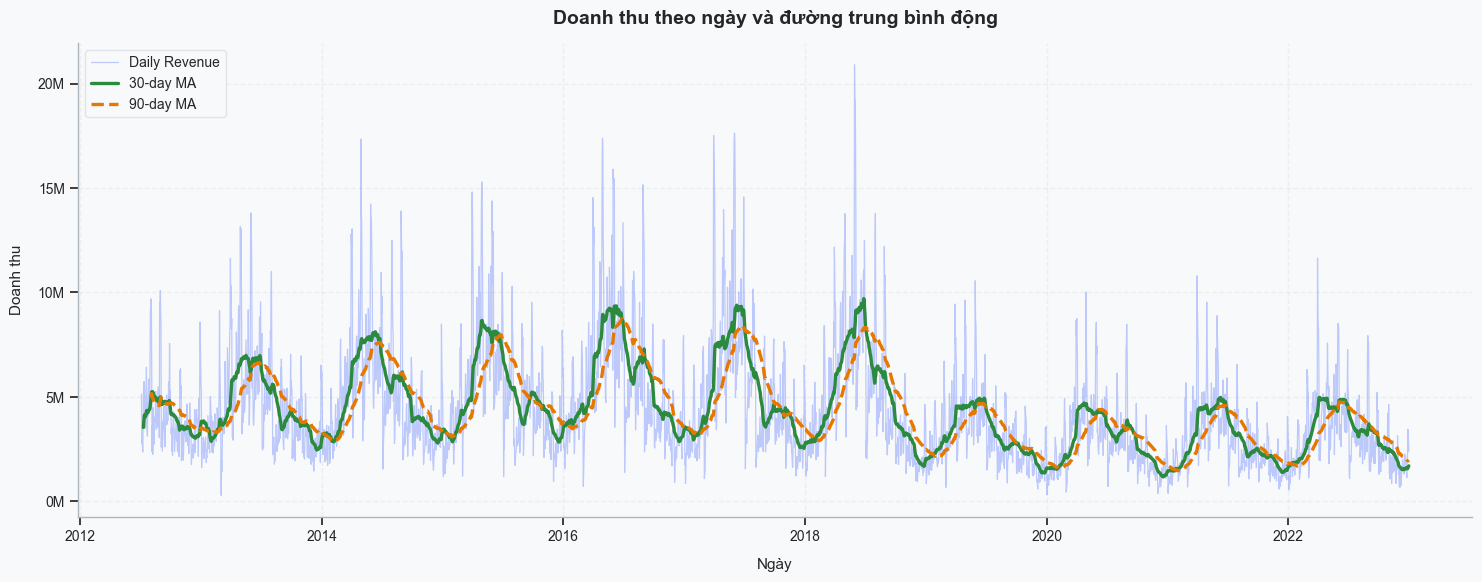

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data=sales, x="Date", y="Revenue", ax=ax, color=LINE_DAILY, linewidth=0.9, alpha=0.45, label="Daily Revenue")
sns.lineplot(data=sales, x="Date", y="rev_30d_ma", ax=ax, color=LINE_MA30, linewidth=2.4, label="30-day MA")
sns.lineplot(data=sales, x="Date", y="rev_90d_ma", ax=ax, color=LINE_MA90, linewidth=2.4, linestyle="--", label="90-day MA")

ax.set_title("Doanh thu theo ngày và đường trung bình động")
ax.set_xlabel("Ngày")
ax.set_ylabel("Doanh thu")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B" if abs(x) >= 1e9 else f"{x/1e6:.0f}M")
)
ax.legend(loc="upper left", frameon=True)
ax.grid(True, axis="y", linestyle="--", alpha=0.45)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

*   **Các phát hiện chính:**

    *   **Giai đoạn hoàng kim (2012 - 2018):** Doanh nghiệp ghi nhận chu kỳ tăng trưởng ổn định, đạt đỉnh cao nhất vào năm 2018. Cụ thể, ngày **30/05/2018** đạt kỷ lục doanh thu ngày cao nhất với **20.91 triệu VND** và tháng **06/2018** đạt đỉnh doanh thu tháng với **0.27 tỷ VND**.

    *   **Tính mùa vụ lặp lại:** Các đường MA 30 ngày cho thấy các đỉnh hình sin lặp lại đều đặn hàng năm, thường đạt cực đại vào giai đoạn giữa năm (Quý 2 và đầu Quý 3), cho thấy nhu cầu mua sắm tập trung mạnh vào các tháng này.

    *   **Sự sụt giảm cấu trúc từ 2019:** Sau đỉnh cao năm 2018, biểu đồ ghi nhận một cú rơi mạnh về doanh thu. Đường MA 90 ngày (xu hướng dài hạn) cho thấy doanh thu đi ngang ở mức thấp (chỉ khoảng 2-5 triệu VND/ngày) kéo dài từ 2019 đến cuối 2022, thấp hơn rất nhiều so với mức trung bình 8-9 triệu VND/ngày thời kỳ trước đó.

*   **Ý nghĩa kinh doanh và Đề xuất hành động:**

    *   **Vấn đề:** Mặc dù lượng truy cập (sessions) vẫn tăng trưởng, doanh thu lại sụt giảm sau 2018. Đây chính là "Nghịch lý tăng trưởng" – doanh nghiệp đang chi tiền để kéo khách hàng nhưng không chuyển đổi thành tiền thực tế thành công.

    *   **Hành động:**

        1.  **Lập kế hoạch theo mùa:** Dựa vào tính chu kỳ, bộ phận kho vận và marketing cần tập trung nguồn lực mạnh nhất vào cuối Quý 1 để đón đầu "mùa gặt" từ tháng 4 đến tháng 7 hàng năm.

        2.  **Tối ưu hóa chuyển đổi:** Cần điều tra sâu nguyên nhân sụt giảm từ năm 2019 (có thể do lỗi hệ thống, đối thủ cạnh tranh mới, hoặc thay đổi chính sách khuyến mãi gây lỗ).

        3.  **Dự báo thay vì nhìn trung bình:** Doanh nghiệp không nên dùng con số doanh thu trung bình (4.29 triệu VND/ngày) để lập kế hoạch cho mọi tháng, mà phải áp dụng mô hình dự báo theo lịch (Time-series) để tối ưu hóa tồn kho.

---

#### 5.1.2. Heatmap Doanh thu theo Tháng (Seasonality & Trend)

Biểu đồ nhiệt (Heatmap) này trình bày tổng doanh thu hàng tháng được chia theo lưới Năm và Tháng. Đây là công cụ đắc lực nhất để các nhà quản trị nhận diện **tính thời vụ (Seasonality)** và **điểm gãy xu hướng (Trend Shift)** trong lịch sử kinh doanh. 

Thay vì chỉ nhìn vào sự tăng trưởng chung, Heatmap cho phép ta trả lời câu hỏi: *"Doanh thu thường bùng nổ vào lúc nào trong năm?"* và *"Mô hình tăng trưởng này có duy trì ổn định qua các năm hay không?"*

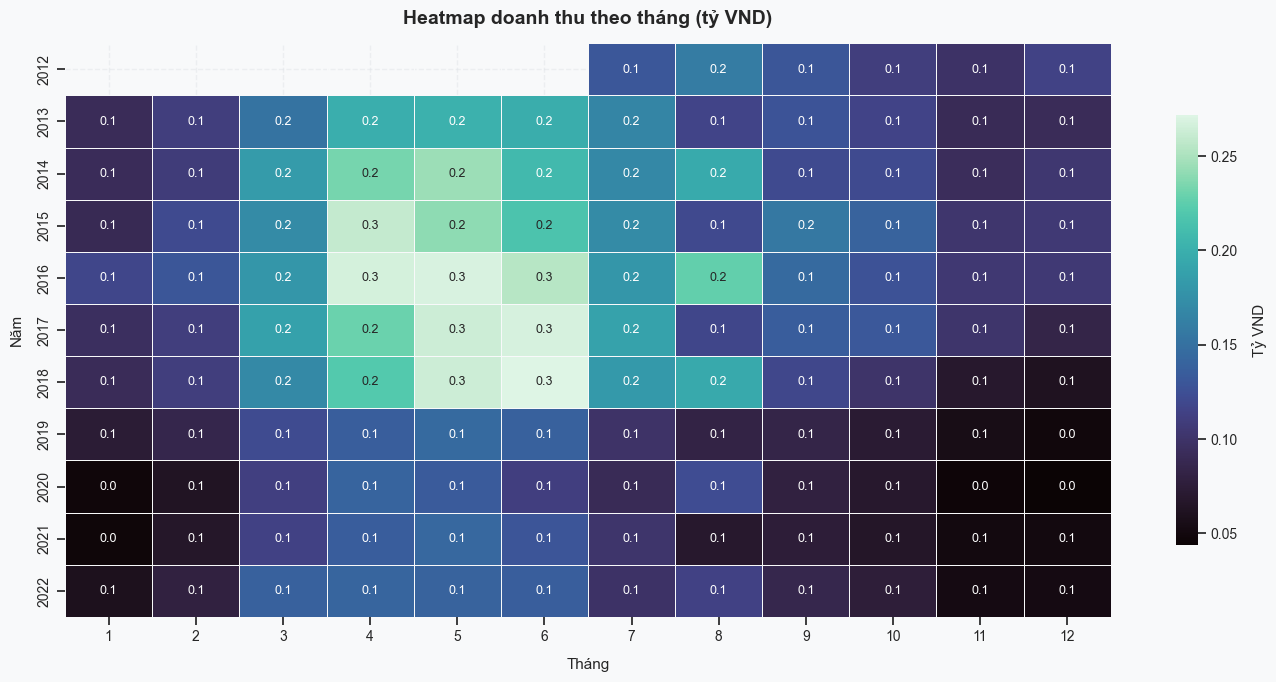

In [21]:
monthly = sales.groupby(["year", "month"], as_index=False).agg(Revenue=("Revenue", "sum"))
monthly_pivot = monthly.pivot(index="year", columns="month", values="Revenue")

plt.figure(figsize=(14, 7))
ax = sns.heatmap(
    monthly_pivot / 1e9,
    cmap=sns.color_palette("mako", as_cmap=True),
    annot=True,
    fmt=".1f",
    linewidths=0.6,
    linecolor="#f8f9fa",
    cbar_kws={"label": "Tỷ VND", "shrink": 0.75},
    annot_kws={"size": 9},
)
ax.set_title("Heatmap doanh thu theo tháng (tỷ VND)", pad=14)
ax.set_xlabel("Tháng")
ax.set_ylabel("Năm")
plt.tight_layout()
plt.show()

* **Các phát hiện chính**

    *   **"Mùa gặt" tập trung vào giữa năm:** Doanh nghiệp có tính thời vụ cực kỳ rõ rệt. Vùng màu sáng nhất (biểu thị mức doanh thu cao từ **0.2 - 0.3 tỷ VND**) tập trung chủ yếu vào giai đoạn từ **Tháng 4 đến Tháng 7**. Đặc biệt, trong giai đoạn 2015-2018, đây là những tháng mang lại dòng tiền chủ lực cho doanh nghiệp.

    *   **Vùng "trũng" doanh thu:** Các tháng đầu năm (Tháng 1-2) và cuối năm (Tháng 11-12) thường ghi nhận mức doanh thu thấp nhất, duy trì ở mức **0.1 tỷ VND** hoặc thấp hơn. Điều này khá lạ đối với ngành thời trang (vốn thường mạnh vào cuối năm), gợi ý rằng danh mục sản phẩm của doanh nghiệp có thể tập trung vào đồ mùa hè hoặc đồ mặc hàng ngày hơn là đồ lễ hội.

    *   **Sự suy giảm rõ rệt sau năm 2018:** Biểu đồ cho thấy một sự thay đổi cấu trúc lớn. Từ năm 2019 trở đi, các "điểm nóng" (màu sáng) gần như biến mất hoàn toàn. Doanh thu hàng tháng bị san phẳng và duy trì ở mức thấp (khoảng 0.1 tỷ VND), ngay cả trong những tháng cao điểm trước đây.

* **Ý nghĩa kinh doanh và Đề xuất hành động**

    *   **Tối ưu hóa ngân sách theo lịch (Budget Allocation):** Doanh nghiệp nên tập trung ngân sách Marketing và các chương trình kích cầu mạnh nhất vào cuối Quý 1 để đón đầu làn sóng mua sắm bắt đầu từ tháng 4. Việc đổ tiền quảng cáo vào tháng 12 có thể không mang lại ROI (lợi nhuận trên vốn đầu tư) tốt như mong đợi do tính thời vụ thấp.

    *   **Quản trị tồn kho (Inventory Management):** Cần có kế hoạch nhập hàng và dự trữ hàng hóa lớn trước tháng 4. Ngược lại, vào cuối năm, doanh nghiệp nên ưu tiên các chương trình giải phóng hàng tồn kho để tránh ứ đọng vốn cho năm tài chính tiếp theo.

    *   **Cảnh báo chiến lược:** Sự sụt giảm doanh thu đồng loạt trên tất cả các tháng từ năm 2019 là một tín hiệu báo động đỏ. Điều này chứng minh rằng sự đi xuống của doanh nghiệp không phải do biến động thị trường ngắn hạn mà là một vấn đề nội tại nghiêm trọng (mất khách hàng trung thành, sản phẩm lỗi thời, hoặc traffic từ các kênh chính bị sụt giảm).

--- 

#### 5.1.3. Doanh thu năm và Hiệu suất Lợi nhuận gộp

Biểu đồ kết hợp (Dual-axis Chart) này cung cấp cái nhìn tổng thể về quy mô tăng trưởng (Doanh thu - cột) đối chiếu với hiệu quả vận hành thực tế (Tỷ lệ biên lợi nhuận gộp - đường). Đây là thước đo sống còn để đánh giá liệu doanh nghiệp đang "tăng trưởng nóng" hay "tăng trưởng bền vững".

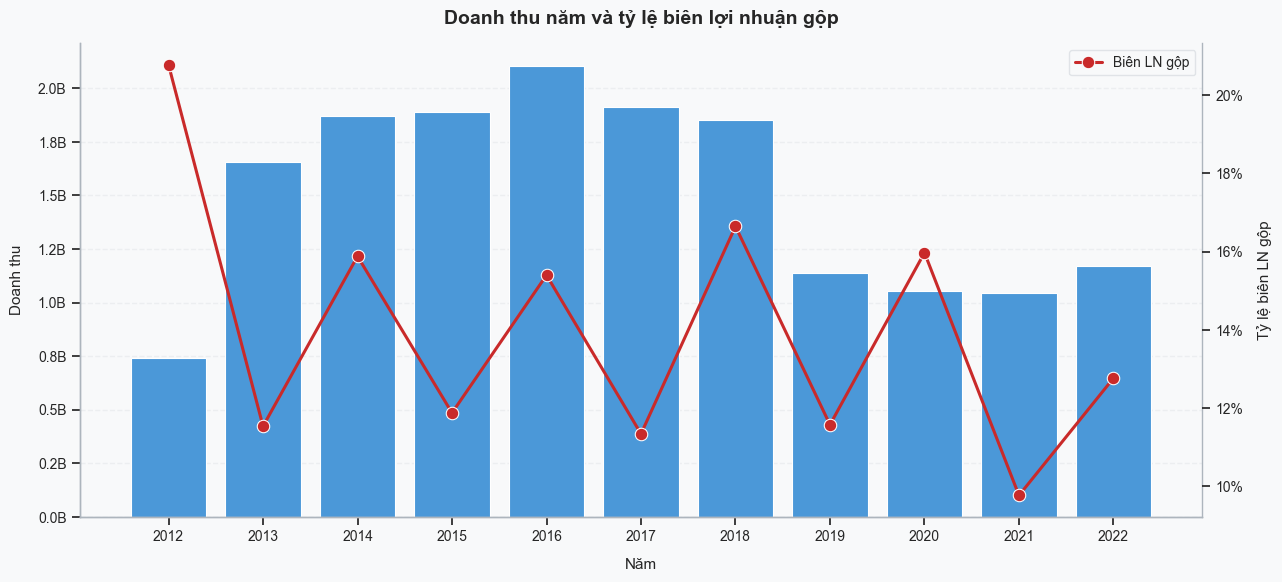

,year,Revenue,COGS,gross_margin,gross_margin_pct,yoy_growth
0,2012,"741,497,748.02","587,461,923.81","154,035,824.21",0.21,NaN
1,2013,"1,657,169,417.27","1,465,980,103.20","191,189,314.07",0.12,1.23
2,2014,"1,871,845,882.80","1,574,607,456.89","297,238,425.91",0.16,0.13
3,2015,"1,889,933,826.92","1,665,441,817.42","224,492,009.50",0.12,0.01
4,2016,"2,104,640,677.54","1,780,559,392.69","324,081,284.85",0.15,0.11
5,2017,"1,911,164,325.28","1,694,385,793.54","216,778,531.74",0.11,-0.09
6,2018,"1,850,122,456.08","1,542,175,766.14","307,946,689.94",0.17,-0.03
7,2019,"1,136,801,441.51","1,005,202,883.72","131,598,557.79",0.12,-0.39
8,2020,"1,054,512,158.79","886,085,097.63","168,427,061.16",0.16,-0.07
9,2021,"1,043,039,819.63","941,130,120.16","101,909,699.47",0.10,-0.01


In [22]:
annual = sales.groupby("year", as_index=False).agg(
    Revenue=("Revenue", "sum"),
    COGS=("COGS", "sum"),
    gross_margin=("gross_margin", "sum")
)
annual["gross_margin_pct"] = annual["gross_margin"] / annual["Revenue"]
annual["yoy_growth"] = annual["Revenue"].pct_change()

fig, ax1 = plt.subplots(figsize=(13, 6))
sns.barplot(data=annual, x="year", y="Revenue", ax=ax1, color=TWIN_FILL, edgecolor="white", linewidth=0.8)
ax1.set_title("Doanh thu năm và tỷ lệ biên lợi nhuận gộp")
ax1.set_xlabel("Năm")
ax1.set_ylabel("Doanh thu")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e9:.1f}B"))

ax2 = ax1.twinx()
sns.lineplot(
    data=annual,
    x=np.arange(len(annual)),
    y="gross_margin_pct",
    marker="o",
    markersize=9,
    ax=ax2,
    color=TWIN_ACCENT,
    linewidth=2.2,
    label="Biên LN gộp",
)
ax2.set_ylabel("Tỷ lệ biên LN gộp")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.grid(False)
ax2.set_xticks(np.arange(len(annual)))
ax2.set_xticklabels(annual["year"].astype(int))
handles, labels = ax2.get_legend_handles_labels()
ax1.legend(handles, labels, loc="upper right", frameon=True)
ax2.get_legend().remove()
ax1.grid(True, axis="y", linestyle="--", alpha=0.45)
sns.despine(ax=ax1, right=False)
sns.despine(ax=ax2, left=False)
plt.tight_layout()
plt.show()

display(annual)

*   **Các phát hiện chính**

    *   **Đỉnh cao và thoái trào:** Doanh thu đạt đỉnh vào năm **2016** với **2.1 tỷ VND**. Tuy nhiên, từ năm 2019, quy mô doanh nghiệp bị thu hẹp đáng kể, rơi xuống mức quanh **1.1 tỷ VND** (giảm gần 50% so với thời kỳ đỉnh cao).

    *   **Cú sốc năm 2019:** Ghi nhận mức tăng trưởng âm kỷ lục **-39% YoY**. Đây là giai đoạn doanh nghiệp mất đi cả quy mô doanh số lẫn hiệu suất sinh lời.

    *   **Biên lợi nhuận thiếu ổn định:** Tỷ lệ biên lợi nhuận gộp không duy trì được sự nhất quán, dao động mạnh từ **10% đến 21%**. Năm 2021 ghi nhận mức thấp kỷ lục (**10%**), cho thấy chi phí giá vốn (COGS) đang gây áp lực cực lớn lên lợi nhuận.

    *   **Tín hiệu hồi phục (2022):** Doanh thu năm 2022 tăng trưởng trở lại ở mức **12% YoY**, đi kèm với sự cải thiện nhẹ trong biên lợi nhuận (lên **13%**).

*   **Ý nghĩa kinh doanh và Đề xuất hành động**

    *   **Tái cấu trúc chi phí:** Với biên lợi nhuận gộp chỉ ở mức 10-13% trong những năm gần đây, doanh nghiệp đang hoạt động với biên độ an toàn rất thấp. Cần rà soát lại các nhà cung cấp và tối ưu hóa chi phí sản xuất (COGS) để đưa biên lợi nhuận quay lại mốc 15-17% như giai đoạn 2016-2018.

    *   **Chuyển trọng tâm từ "Doanh thu" sang "Lợi nhuận":** Thay vì cố gắng đẩy doanh số bằng mọi giá (có thể thông qua khuyến mãi làm bào mòn margin), doanh nghiệp nên ưu tiên các dòng sản phẩm có biên lợi nhuận cao để ổn định dòng tiền.

    *   **Phân tích nguyên nhân suy thoái dài hạn:** Doanh thu năm 2022 vẫn chỉ bằng khoảng một nửa so với năm 2016. Doanh nghiệp cần xác định xem đây là do sự thay đổi của thị trường hay do mất đi các lợi thế cạnh tranh cốt lõi để có chiến lược tái định vị phù hợp.

---

### 5.2. Nghịch lý Tăng trưởng: Lưu lượng truy cập (Traffic) vs. Hiệu quả chuyển đổi

Biểu đồ trục kép (Dual-axis Chart) này đối chiếu quy mô tiếp cận khách hàng (Sessions - cột xanh) với hiệu quả chuyển đổi thực tế (Orders per 1,000 visitors - đường đỏ) qua các năm. Đây là công cụ quan trọng để xác định xem sự tăng trưởng về lượng có thực sự đi đôi với sự tăng trưởng về chất hay không.

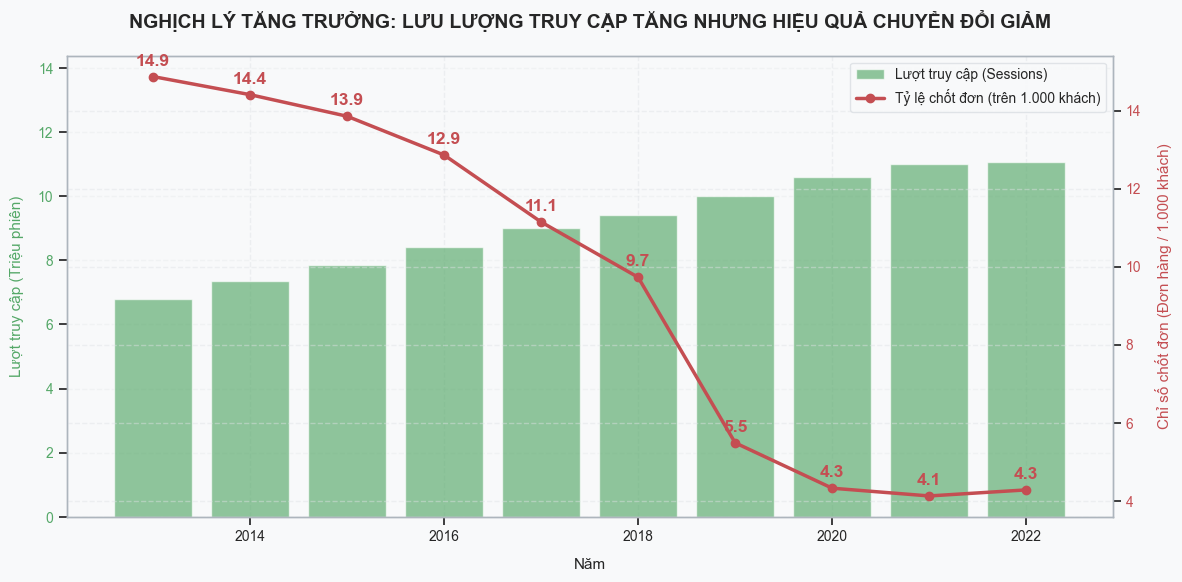

In [23]:
# Khởi tạo figure và trục chính (ax1)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Vẽ biểu đồ cột (Sessions) trên trục ax1
max_sessions = yearly_kpis["sessions"].max() / 1e6
ax1.bar(yearly_kpis.index, yearly_kpis["sessions"] / 1e6, color=GREEN, alpha=0.65, label="Lượt truy cập (Sessions)")
ax1.set_xlabel("Năm")
ax1.set_ylabel("Lượt truy cập (Triệu phiên)", color=GREEN)
ax1.tick_params(axis='y', labelcolor=GREEN)
ax1.set_ylim(0, max_sessions * 1.3)
ax1.set_title("NGHỊCH LÝ TĂNG TRƯỞNG: LƯU LƯỢNG TRUY CẬP TĂNG NHƯNG HIỆU QUẢ CHUYỂN ĐỔI GIẢM", 
             fontsize=14, fontweight="bold", pad=20)

# Khởi tạo trục phụ (ax2) dùng chung trục x
ax2 = ax1.twinx()

# Vẽ biểu đồ đường (Orders per 1k visitors) trên trục ax2
ax2.plot(yearly_kpis.index, yearly_kpis["orders_per_1000_visitors"], 
         color=RED, marker="o", linewidth=2.5, label="Tỷ lệ chốt đơn (trên 1.000 khách)")
ax2.set_ylabel("Chỉ số chốt đơn (Đơn hàng / 1.000 khách)", color=RED)
ax2.tick_params(axis="y", labelcolor=RED)

# Xử lý Legend: Gộp legend từ cả 2 trục
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True)

# Thêm chú thích số liệu (Annotation) cho đường line
for year, value in yearly_kpis["orders_per_1000_visitors"].items():
    ax2.annotate(f"{value:.1f}", 
                 (year, value), 
                 textcoords="offset points", 
                 xytext=(0, 8), 
                 ha="center", 
                 color=RED,
                 fontweight='bold')

# Tối ưu hóa hiển thị
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

*   **Các phát hiện chính:**

    *   **Quy mô tiếp cận (Sessions) tăng trưởng ổn định:** Lượng truy cập vào hệ thống liên tục tăng từ mức xấp xỉ 6,8 triệu phiên (năm 2013) lên đến hơn 11 triệu phiên vào năm 2022.

    *   **Hiệu quả chuyển đổi sụt giảm nghiêm trọng:** Trái ngược với đà tăng của traffic, tỷ lệ chốt đơn (Orders per 1,000 visitors) lại lao dốc liên tục qua các năm, từ mức đỉnh 14,9 (năm 2013) xuống chỉ còn 4,3 đơn hàng trên mỗi 1.000 khách truy cập vào năm 2022.

    *   **Điểm gãy năm 2019:** Giai đoạn từ 2019 - 2020 chứng kiến tốc độ sụt giảm tỷ lệ chuyển đổi nhanh nhất (từ 9,7 xuống 4,3), trùng khớp với giai đoạn sụt giảm doanh thu tổng thể đã quan sát thấy ở các biểu đồ trước.

*   **Ý nghĩa kinh doanh và Đề xuất hành động:**

    *   **Nghịch lý "Traffic ảo":** Doanh nghiệp không còn gặp vấn đề về việc thu hút khách hàng (Acquisition), nhưng lại gặp rào cản lớn trong việc thuyết phục họ mua hàng (Conversion). Điều này cho thấy lưu lượng truy cập tăng thêm đang ngày càng kém chất lượng hoặc trải nghiệm mua sắm không còn đủ hấp dẫn.

    *   **Tối ưu hóa phễu chuyển đổi (CRO):** Cần rà soát lại các nguồn truy cập (đặc biệt là các kênh trả phí) để xác định xem có đang thu hút sai tệp khách hàng mục tiêu hay không.

    *   **Audit trải nghiệm người dùng:** Việc tỷ lệ chuyển đổi giảm sâu đòi hỏi một cuộc kiểm tra toàn diện về website/app (UX/UI), tốc độ tải trang, và tính cạnh tranh của giá cả so với các đối thủ mới nổi từ sau năm 2019.
    
    *   **Hành động mục tiêu:** Chuyển trọng tâm ngân sách từ việc "mua traffic" thuần túy sang các chiến dịch remarketing nhắm vào nhóm khách hàng cũ và tối ưu hóa trang thanh toán để cứu vãn tỷ lệ chuyển đổi.

---

### 5.3. Hiệu suất Danh mục: Quy mô Doanh thu vs. Hiệu quả Lợi nhuận

Cặp biểu đồ này đối chiếu giữa **quy mô doanh thu** (Net Sales) và **hiệu suất sinh lời** (Gross Margin %) của từng danh mục. Đây là bước phân tích trọng tâm để phân loại danh mục theo mô hình ma trận chiến lược (như BCG), giúp doanh nghiệp xác định đâu là "cỗ máy in tiền" và đâu là "ngôi sao tiềm năng".

*   **Biểu đồ doanh thu thuần (Trái):** Cho thấy tỷ trọng đóng góp của từng nhóm hàng vào tổng dòng tiền. Nó giúp trả lời câu hỏi: *"Sản phẩm nào đang nuôi sống doanh nghiệp?"*

*   **Biểu đồ biên lợi nhuận gộp (Phải):** Đo lường hiệu quả kinh doanh trên mỗi đồng doanh thu sau khi trừ giá vốn. Nó trả lời câu hỏi: *"Sản phẩm nào kinh doanh hiệu quả nhất?"*

*   **Góc nhìn kết hợp:** Sự chênh lệch giữa quy mô và lợi nhuận thường chỉ ra các vấn đề về chi phí vận hành, giá vốn hoặc chiến lược chiết khấu không đồng nhất giữa các ngành hàng.

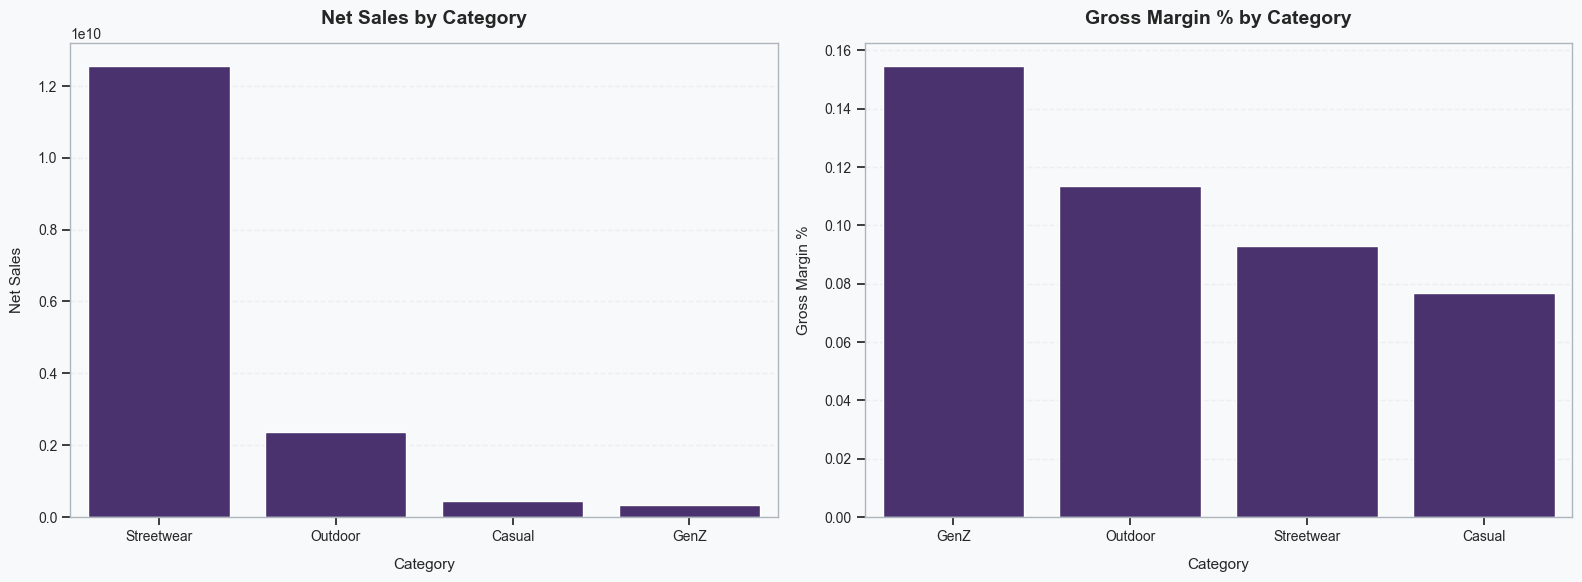

,category,net_sales,quantity,orders,discount,gross_profit,gross_margin_pct,discount_rate
3,Streetwear,"12,558,477,099.17",1768826,389543,"572,869,253.45","1,165,807,511.55",0.09,0.04
2,Outdoor,"2,353,396,796.86",1170000,200454,"141,485,957.34","267,034,092.02",0.11,0.06
0,Casual,"440,285,193.75",107469,23600,"20,363,189.60","33,740,765.23",0.08,0.04
1,GenZ,"328,710,175.65",166848,37054,"14,888,919.71","50,836,377.50",0.15,0.04


In [24]:
category_perf = transactions.groupby("category", as_index=False).agg(
    net_sales=("net_sales", "sum"),
    quantity=("quantity", "sum"),
    orders=("order_id", "nunique"),
    discount=("discount_amount", "sum"),
    gross_profit=("gross_profit", "sum")
)
category_perf["gross_margin_pct"] = category_perf["gross_profit"] / category_perf["net_sales"]
category_perf["discount_rate"] = category_perf["discount"] / (category_perf["net_sales"] + category_perf["discount"])
category_perf = category_perf.sort_values("net_sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=category_perf, x="category", y="net_sales", ax=axes[0])
axes[0].set_title("Net Sales by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Net Sales")

sns.barplot(data=category_perf.sort_values("gross_margin_pct", ascending=False), x="category", y="gross_margin_pct", ax=axes[1])
axes[1].set_title("Gross Margin % by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Gross Margin %")

plt.tight_layout()
plt.show()

display(category_perf)

* **Các phát hiện chính**

    *   **Streetwear là "Cỗ máy doanh thu" áp đảo:** Với doanh thu thuần đạt hơn **12,56 tỷ VND**, Streetwear chiếm tỷ trọng tuyệt đối so với các nhóm còn lại (gấp hơn 5 lần danh mục đứng thứ hai là Outdoor). Tuy nhiên, biên lợi nhuận gộp của nhóm này chỉ ở mức trung bình thấp (**9%**).

    *   **GenZ là "Ngôi sao hiệu suất":** Mặc dù có quy mô doanh thu nhỏ nhất (**0,33 tỷ VND**), nhưng danh mục GenZ lại sở hữu biên lợi nhuận cao nhất toàn hệ thống đạt **15%**. Điều này cho thấy đây là nhóm hàng có khả năng định giá tốt hoặc tối ưu chi phí giá vốn cực kỳ hiệu quả.

    *   **Outdoor - Sự cân bằng ổn định:** Danh mục này đứng thứ hai về cả doanh thu (**2,35 tỷ VND**) lẫn biên lợi nhuận (**11%**), đóng vai trò là "vùng đệm" an toàn cho lợi nhuận tổng thể.

    *   **Casual - Điểm yếu cần lưu ý:** Nhóm hàng này ghi nhận biên lợi nhuận thấp nhất (**8%**) đi kèm với quy mô doanh thu khiêm tốn (**0,44 tỷ VND**).

* **Ý nghĩa kinh doanh và Đề xuất hành động**

    *   **Tối ưu hóa biên lợi nhuận cho Streetwear:** Vì quy mô của Streetwear quá lớn, chỉ cần cải thiện **1%** biên lợi nhuận cũng mang lại lợi nhuận tuyệt đối lớn hơn rất nhiều so với các ngành hàng khác. Doanh nghiệp cần rà soát lại chuỗi cung ứng hoặc giảm bớt các chương trình chiết khấu không cần thiết cho nhóm này.

    *   **Chiến lược tăng trưởng cho danh mục GenZ:** Với hiệu suất sinh lời cao (15%), doanh nghiệp nên đầu tư thêm ngân sách Marketing để mở rộng quy mô (Scale-up) nhóm hàng này. Mục tiêu là biến GenZ từ một nhóm hàng nhỏ thành một trụ cột doanh thu mới mà vẫn giữ được biên lợi nhuận tốt.

    *   **Tái cấu trúc hoặc loại bỏ danh mục Casual:** Casual đang rơi vào vùng nguy hiểm khi cả quy mô và hiệu suất đều thấp. Cần kiểm tra xem chi phí giá vốn (COGS) của nhóm này có đang quá cao hay không, hoặc liệu có nên dồn nguồn lực từ Casual sang các nhóm hiệu quả hơn như GenZ hay Outdoor.

    *   **Kiểm soát chiết khấu:** Tỷ lệ chiết khấu (discount rate) hiện đang duy trì ở mức 4-6% cho các ngành hàng. Cần đảm bảo rằng việc duy trì doanh thu khủng cho Streetwear không phải là hệ quả của việc lạm dụng giảm giá quá sâu.

---

### 5.4. Hiệu quả Kinh tế của Chương trình Khuyến mãi

Cặp trực quan hoá này cung cấp cái nhìn đối lập giữa **tăng trưởng quy mô** và **hiệu quả sinh lời** dưới tác động của các chương trình khuyến mãi. Đây là lớp phân tích "vàng" giúp doanh nghiệp xác định liệu chiến lược giảm giá hiện tại đang giúp mở rộng thị phần hay thực chất là đang "đốt tiền" để mua doanh thu.

In [25]:
def fmt_billions(value, _):
    return f"{value / 1e9:.1f}B"

def fmt_millions(value, _):
    return f"{value / 1e6:.1f}M"

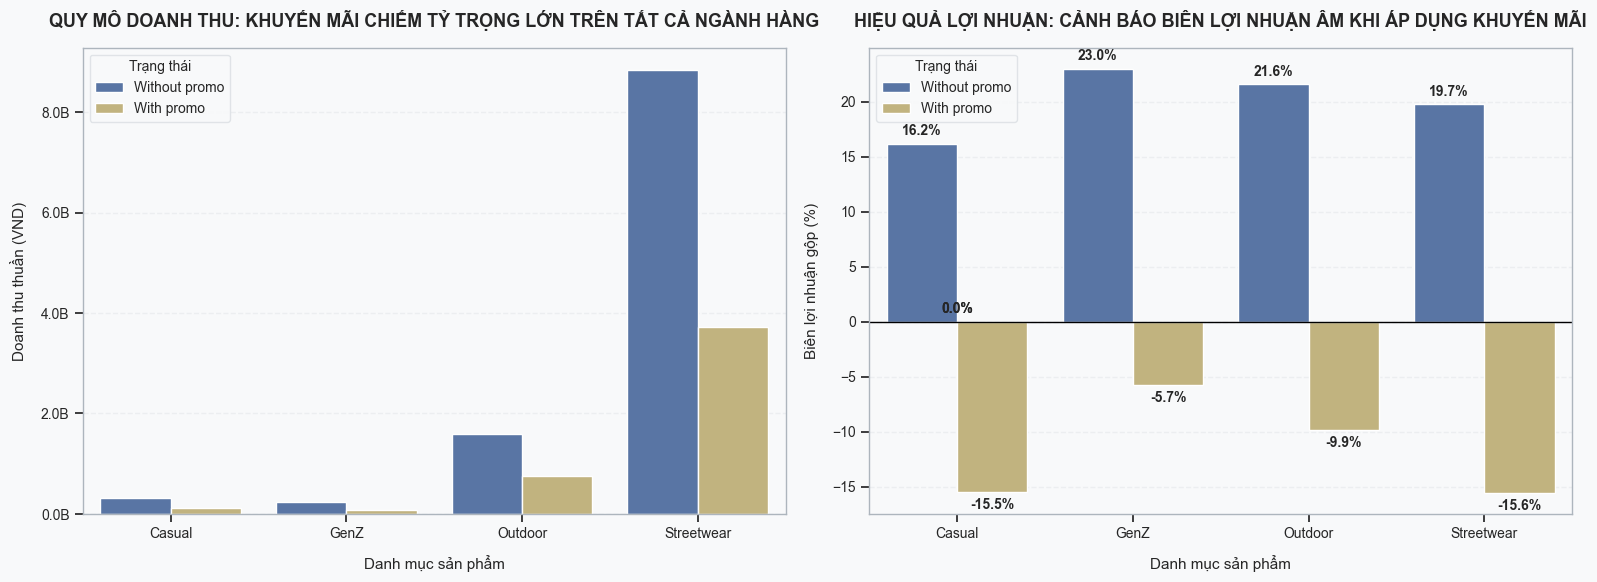

In [26]:
# Thiết lập cấu trúc biểu đồ
plot_data = promo_perf.reset_index().copy() 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: So sánh Doanh thu Thuần
sns.barplot(
    data=plot_data,
    x="category",
    y="net_sales",
    hue="promo_label",
    ax=axes[0],
    palette=[BLUE, GOLD]
)

axes[0].set_title("QUY MÔ DOANH THU: KHUYẾN MÃI CHIẾM TỶ TRỌNG LỚN TRÊN TẤT CẢ NGÀNH HÀNG", 
                  fontsize=13, fontweight="bold", pad=15)
axes[0].set_xlabel("Danh mục sản phẩm")
axes[0].set_ylabel("Doanh thu thuần (VND)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_billions))
axes[0].legend(title="Trạng thái")

# Biểu đồ 2: So sánh Biên lợi nhuận gộp
sns.barplot(
    data=plot_data,
    x="category",
    y="gross_margin_pct",
    hue="promo_label",
    ax=axes[1],
    palette=[BLUE, GOLD]
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("HIỆU QUẢ LỢI NHUẬN: CẢNH BÁO BIÊN LỢI NHUẬN ÂM KHI ÁP DỤNG KHUYẾN MÃI", 
                  fontsize=13, fontweight="bold", pad=15)
axes[1].set_xlabel("Danh mục sản phẩm")
axes[1].set_ylabel("Biên lợi nhuận gộp (%)")
axes[1].legend(title="Trạng thái")

for patch in axes[1].patches:
    height = patch.get_height()
    if not np.isnan(height):
        x = patch.get_x() + patch.get_width() / 2
        va = "bottom" if height >= 0 else "top"
        xytext = (0, 4) if height >= 0 else (0, -4)
        
        axes[1].annotate(f"{height:.1f}%", 
                         (x, height), 
                         ha="center", va=va, 
                         fontsize=10, fontweight='bold',
                         xytext=xytext, textcoords="offset points")

plt.tight_layout()
plt.show()

* **Các phát hiện chính**

    * **Khuyến mãi là động lực doanh thu đáng kể:** Ở tất cả các danh mục, doanh thu từ các đơn hàng có khuyến mãi (With promo) chiếm tỷ trọng rất lớn. Đặc biệt với **Streetwear**, quy mô doanh thu từ khuyến mãi đạt mức hàng tỷ đồng, cho thấy khách hàng của nhóm này có độ nhạy cảm về giá rất cao.

    * **Cảnh báo đỏ về Biên lợi nhuận gộp:** Một nghịch lý nguy hiểm hiện rõ khi nhìn vào biểu đồ bên phải. Trong khi các đơn hàng không khuyến mãi duy trì biên lợi nhuận rất tốt (từ **16.2% đến 23.0%**), thì **tất cả** các đơn hàng có khuyến mãi đều đang ghi nhận mức **lợi nhuận âm**.

    * **Mức độ thiệt hại theo ngành hàng:** 

        * **Streetwear và Casual** chịu ảnh hưởng nặng nề nhất với biên lợi nhuận gộp lần lượt là **-15.6%** và **-15.5%** khi áp dụng promo.

        * Ngay cả nhóm hàng có biên lợi nhuận gốc cao nhất là **GenZ (23.0%)** cũng rơi xuống mức **-5.7%** khi chạy chương trình.

    * **Khoảng cách lợi nhuận cực lớn:** Sự chênh lệch biên độ lên tới hơn **30 điểm phần trăm** (ví dụ Streetwear: từ +19.7% xuống -15.6%) cho thấy mức chiết khấu hiện tại đang vượt quá xa ngưỡng bù đắp của giá vốn (COGS).

* **Ý nghĩa kinh doanh và Đề xuất hành động**

    * **Tư duy lại chiến lược chiết khấu:** Doanh nghiệp đang lỗ trên mỗi sản phẩm bán ra trong chương trình khuyến mãi. Cần ngay lập tức tính toán lại **điểm hòa vốn (Break-even point)** để thiết lập lại mức giảm giá tối đa (Max Discount) không được phép làm biên lợi nhuận gộp rơi xuống mức âm.

    * **Dừng chiến dịch "Bán bằng mọi giá":** Tăng trưởng doanh thu (Volume) mà không đi kèm lợi nhuận (Profit) là chiến lược không bền vững. Cần rà soát và loại bỏ các mã hàng đang bị lạm dụng khuyến mãi sâu dẫn đến lỗ nặng.

    * **Tối ưu hóa dựa trên biên độ lợi nhuận:** Nhóm **GenZ** hiện có mức lỗ thấp nhất khi chạy promo (-5.7%). Đây có thể là nhóm hàng tiềm năng để thử nghiệm các hình thức khuyến mãi thông minh hơn (như tặng quà, combo) thay vì giảm giá trực tiếp để đưa biên lợi nhuận về mức dương.
    
    * **Kiểm tra vận hành:** Cần điều tra xem có hiện tượng "cộng dồn khuyến mãi" (Discount Stacking) ngoài kiểm soát hoặc lỗi trong việc thiết lập giá bán thấp hơn giá vốn hệ thống hay không.

---

### 5.5. Chiến lược Quản trị Rủi ro Hoàn trả: Từ Nguyên nhân đến Điểm nóng

Báo cáo này kết hợp hai góc nhìn bổ trợ: **Phân tích Pareto** để định vị các lý do gây thiệt hại tài chính lớn nhất và **Ma trận nhiệt** để xác định chính xác các phân khúc sản phẩm đang gặp lỗi vận hành. Việc hợp nhất này cho phép doanh nghiệp không chỉ biết "Tại sao" khách hàng rời đi mà còn biết "Ở đâu" cần can thiệp ngay lập tức.

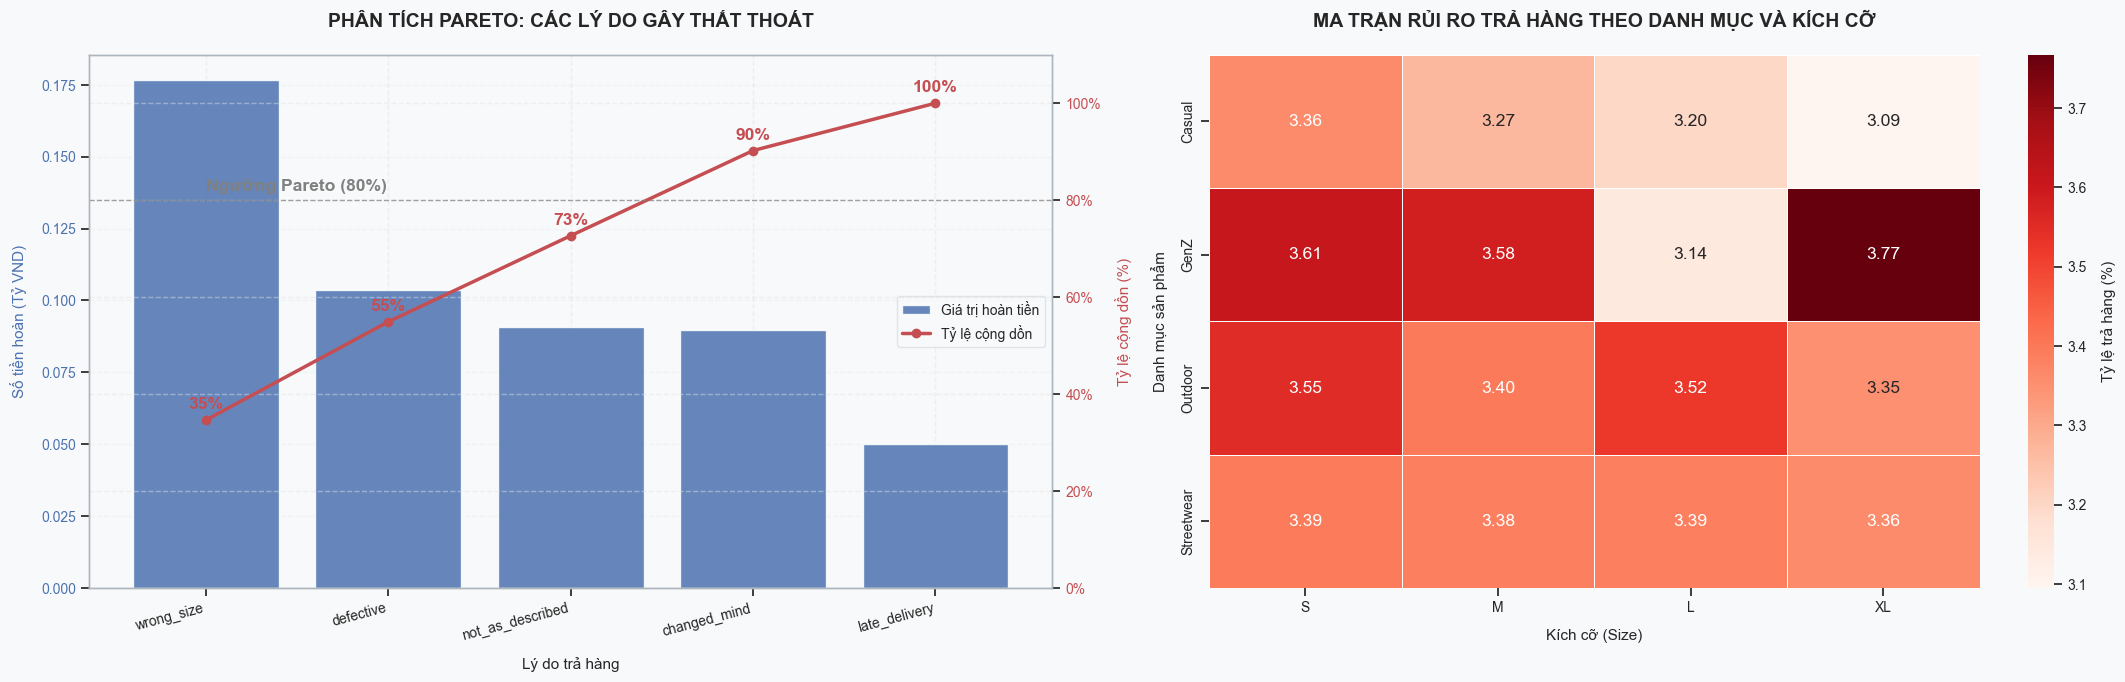

In [27]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(22, 7))

# SUBPLOT 1 (Bên trái): BIỂU ĐỒ PARETO
ax1.bar(return_reasons["return_reason"], return_reasons["total_refund"] / 1e9, color=BLUE, alpha=0.85, label="Giá trị hoàn tiền")
ax1.set_ylabel("Số tiền hoàn (Tỷ VND)", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_xlabel("Lý do trả hàng")

ax1.set_title("PHÂN TÍCH PARETO: CÁC LÝ DO GÂY THẤT THOÁT", fontsize=14, fontweight="bold", pad=20)
ax1.set_xticks(range(len(return_reasons["return_reason"])))
ax1.set_xticklabels(return_reasons["return_reason"], rotation=15, ha="right")

ax2 = ax1.twinx()
ax2.plot(return_reasons["return_reason"], return_reasons["cum_refund_pct"], color=RED, marker="o", linewidth=2.5, label="Tỷ lệ cộng dồn")

ax2.axhline(80, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax2.annotate("Ngưỡng Pareto (80%)", xy=(0, 82), color="gray", fontweight="bold")

ax2.set_ylabel("Tỷ lệ cộng dồn (%)", color=RED)
ax2.tick_params(axis="y", labelcolor=RED)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 110)

for i, value in enumerate(return_reasons["cum_refund_pct"]):
    ax2.annotate(f"{value:.0f}%", 
                 (i, value), 
                 textcoords="offset points", 
                 xytext=(0, 8), 
                 ha="center", 
                 color=RED, 
                 fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", frameon=True)
ax1.grid(True, axis="y", linestyle="--", alpha=0.3)


# SUBPLOT 2 (Bên phải): MA TRẬN NHIỆT (HEATMAP)
sns.heatmap(
    return_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={"label": "Tỷ lệ trả hàng (%)"},
    ax=ax3 
)

ax3.set_title("MA TRẬN RỦI RO TRẢ HÀNG THEO DANH MỤC VÀ KÍCH CỠ", 
              fontsize=14, fontweight="bold", pad=20)
ax3.set_xlabel("Kích cỡ (Size)")
ax3.set_ylabel("Danh mục sản phẩm")

plt.tight_layout()
plt.show()

####  1. Phân tích Pareto: Nhận diện 80% thất thoát tài chính

Dựa trên biểu đồ bên trái, chúng ta thấy rõ quy luật tập trung của các lý do trả hàng:

*   **"Sai kích cỡ" (Wrong size) là trọng tâm:** Đây là lý do đơn lẻ lớn nhất, chiếm **35%** tổng giá trị hoàn tiền. Điều này khẳng định rằng rủi ro lớn nhất không nằm ở chất lượng sản phẩm hay vận chuyển, mà nằm ở khâu **tư vấn và quy chuẩn kích cỡ**.

*   **Nhóm lý do cốt lõi (Top 3):** Tổng hợp ba lý do `wrong_size`, `defective` (lỗi sản phẩm) và `not_as_described` (sai mô tả) đã gây ra **73%** tổng thiệt hại tài chính. 

*   **Ngưỡng tối ưu:** Nếu doanh nghiệp tập trung xử lý triệt để 4 nhóm lý do đầu tiên, chúng ta có thể cứu vãn đến **90%** dòng tiền bị mất đi do hoàn trả. Các yếu tố khách quan như `late_delivery` (giao hàng trễ) chỉ đóng góp một phần rất nhỏ (10% cuối cùng).

#### 2. Ma trận Nhiệt: Giải mã các "Điểm nóng" theo Danh mục và Kích cỡ

Biểu đồ bên phải giúp cụ thể hóa vấn đề "Sai kích cỡ" bằng cách soi chiếu tỷ lệ trả hàng trên từng tổ hợp sản phẩm:

*   **GenZ - XL là điểm rủi ro cao nhất:** Tỷ lệ trả hàng ở phân khúc khách hàng GenZ với kích cỡ XL đạt mức báo động **3.77%**. Điều này cho thấy sự không tương thích nghiêm trọng giữa rập (pattern) thiết kế và hình thể thực tế của nhóm khách hàng trẻ ở các size lớn.

*   **Outdoor - Nghịch lý ở Size S:** Trái ngược với các nhóm khác, ngành hàng Outdoor lại gặp vấn đề lớn nhất ở **Size S (3.55%)**. Điều này gợi ý rằng các sản phẩm dã ngoại đang được làm với form dáng quá rộng so với tiêu chuẩn người dùng size nhỏ.

*   **Sự ổn định của Streetwear:** Đây là danh mục có sự đồng nhất cao nhất, tỷ lệ trả hàng duy trì ổn định quanh mức **3.36% - 3.39%** trên tất cả các kích cỡ, cho thấy quy trình sản xuất và tư vấn của dòng hàng chủ lực này đang vận hành rất tốt.

#### 3. Ý nghĩa kinh doanh và Đề xuất hành động hợp nhất

| Chỉ số trọng điểm | Giá trị | Ý nghĩa |
| :--- | :--- | :--- |
| **Lý do hàng đầu** | Wrong Size (35%) | Cần ưu tiên cải cách bảng tư vấn size |
| **Điểm nóng (Hotspot)** | GenZ - XL (3.77%) | Cần lấy lại số đo thực tế và sửa rập sản xuất |
| **Tỷ lệ mục tiêu** | < 3.20% | Ngưỡng an toàn (dựa trên nhóm Casual XL) |

**Hành động chiến lược:**

1.  **Chuẩn hóa bảng Size cho GenZ & Outdoor:** Đây là hai ưu tiên hàng đầu để giảm tỷ lệ trả hàng. Cần bổ sung các công cụ tư vấn size thông minh (Virtual Fitting) hoặc ghi chú trực tiếp: *"Form rộng - nên lùi 1 size"* cho nhóm Outdoor S.

2.  **Thắt chặt QC cho nhóm hàng lỗi:** Vì `defective` chiếm vị trí thứ 2 trong Pareto (tăng tỷ lệ cộng dồn từ 35% lên 55%), cần tăng cường kiểm tra chất lượng tại kho đóng gói để giảm chi phí logistics ngược.

3.  **Tối ưu hóa nội dung Marketing:** Cập nhật hình ảnh và mô tả sản phẩm chân thực hơn để giải quyết lý do "không đúng mô tả", giúp giảm thêm **18%** rủi ro cộng dồn (từ 55% lên 73%).

---

### 5.6. Phân khúc Khách hàng RFM: Định danh "Xương sống" của Doanh nghiệp

Cặp trực quan hóa này thực hiện phân rã tệp khách hàng dựa trên mô hình RFM (Recency, Frequency, Monetary). Đây là "la bàn" chiến lược giúp bộ phận Marketing chuyển từ tư duy tiếp cận đại trà sang cá nhân hóa dựa trên giá trị thực tế mà khách hàng mang lại.


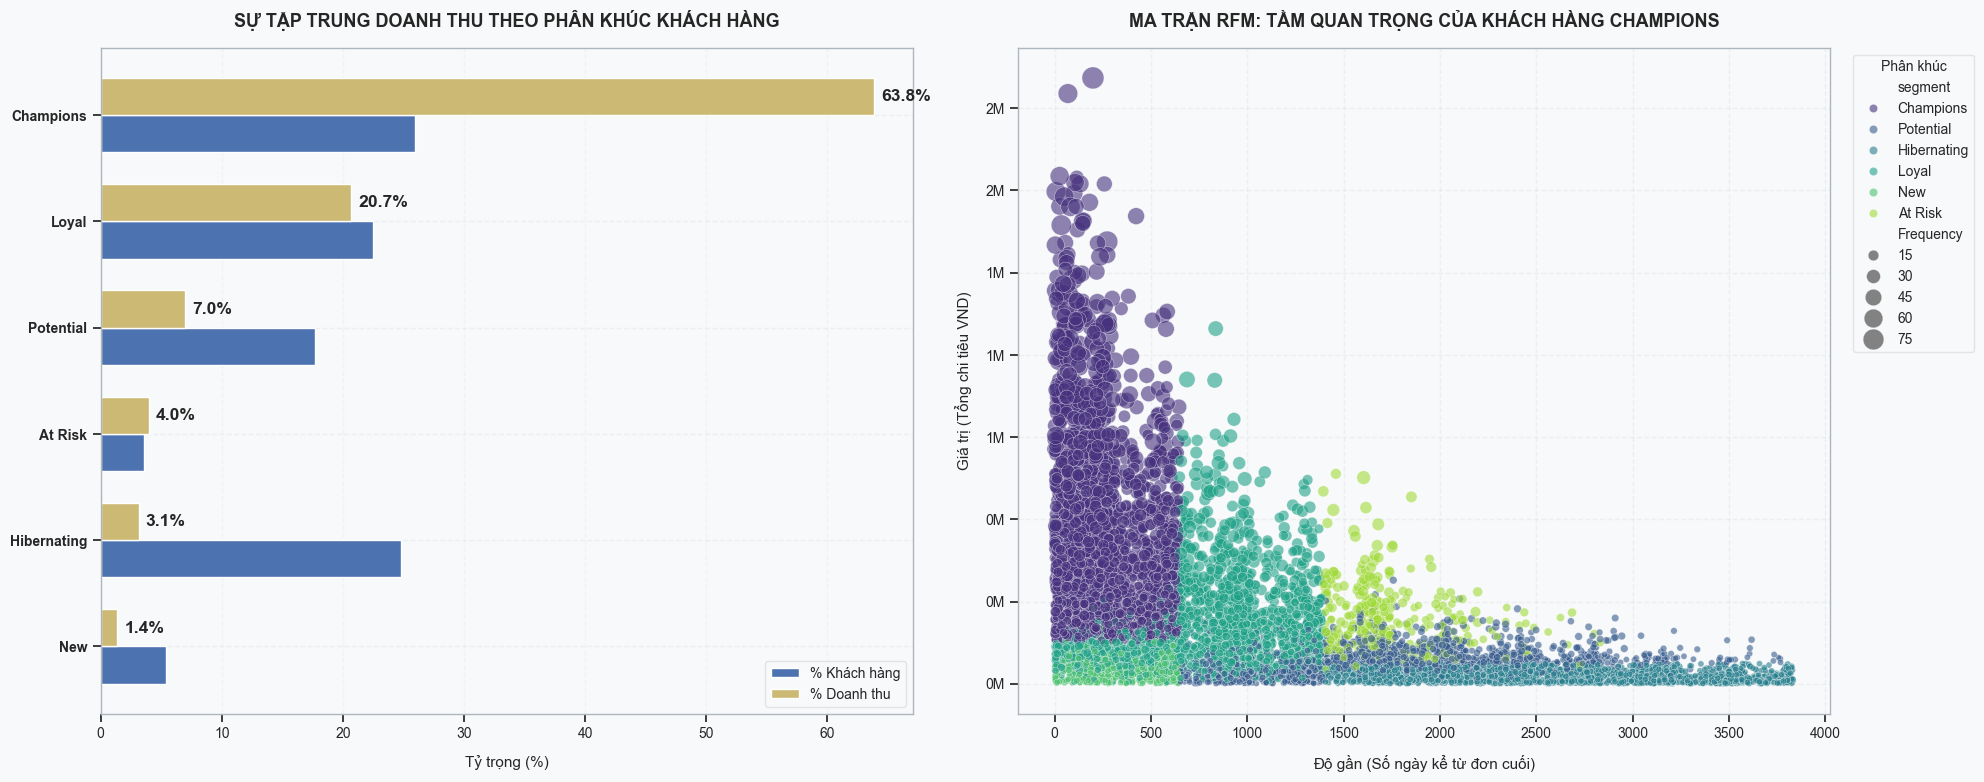

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# SUBPLOT 1 (Trái): Tỷ trọng Khách hàng vs. Doanh thu theo Phân khúc
segment_plot = segment_summary.reset_index().rename(columns={"segment": "Segment"})
segment_plot = segment_plot.sort_values("revenue_share_pct", ascending=True)

y_pos = np.arange(len(segment_plot))
height = 0.35

# Vẽ thanh ngang kép
ax1.barh(y_pos - height/2, segment_plot["customer_share_pct"], height=height, color=BLUE, label="% Khách hàng")
ax1.barh(y_pos + height/2, segment_plot["revenue_share_pct"], height=height, color=GOLD, label="% Doanh thu")

# Định dạng trục và nhãn
ax1.set_yticks(y_pos)
ax1.set_yticklabels(segment_plot["Segment"], fontweight='bold')
ax1.set_xlabel("Tỷ trọng (%)")
ax1.set_title("SỰ TẬP TRUNG DOANH THU THEO PHÂN KHÚC KHÁCH HÀNG", fontsize=13, fontweight="bold", pad=15)
ax1.legend(loc="lower right", frameon=True)

# Ghi chú số liệu % doanh thu lên đầu thanh
for i, value in enumerate(segment_plot["revenue_share_pct"]):
    ax1.annotate(f"{value:.1f}%", (value, y_pos[i] + height/2), 
                 xytext=(5, 0), textcoords="offset points", va="center", fontweight='bold')

ax1.grid(True, axis='x', linestyle='--', alpha=0.3)


# SUBPLOT 2 (Phải): Ma trận Phân tán RFM (Scatter Plot)
rfm_sample = rfm.sample(min(10000, len(rfm)), random_state=42)
sns.scatterplot(
    data=rfm_sample,
    x="Recency",
    y="Monetary",
    hue="segment",
    size="Frequency",
    sizes=(20, 250),
    alpha=0.6,
    ax=ax2,
    palette="viridis"
)

ax2.set_title("MA TRẬN RFM: TẦM QUAN TRỌNG CỦA KHÁCH HÀNG CHAMPIONS", fontsize=13, fontweight="bold", pad=15)
ax2.set_xlabel("Độ gần (Số ngày kể từ đơn cuối)")
ax2.set_ylabel("Giá trị (Tổng chi tiêu VND)")

ax2.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Phân khúc", frameon=True)

ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}M'))

plt.tight_layout()
plt.show()

#### 1. Các phát hiện chính

*   **Nguyên lý Pareto hiện hữu rõ rệt:** Nhóm **Champions** chỉ chiếm khoảng **25%** số lượng khách hàng nhưng lại đóng góp tới gần **64% tổng doanh thu** của doanh nghiệp. Đây chính là nhóm "xương sống" quyết định sự sinh tồn của hệ thống.

*   **Nghịch lý nhóm Hibernating:** Nhóm khách hàng đang "ngủ đông" (Hibernating) chiếm tỷ trọng ngang ngửa nhóm Champions (**25%**) nhưng chỉ mang lại vỏn vẹn **3.1%** doanh thu. Điều này cho thấy doanh nghiệp đang sở hữu một tệp khách hàng cũ rất lớn nhưng đã mất kết nối từ lâu.

*   **Nhận diện chân dung Champions (Scatter Plot):** Biểu đồ phân tán bên phải giải thích lý do tại sao nhóm Champions (màu tím) lại quan trọng đến thế. Các điểm dữ liệu này tập trung sát trục tung (**Recency thấp** - vừa mua hàng xong) và nằm ở vùng cao nhất của trục hoành (**Monetary cao** - chi tiêu lớn), đi kèm với kích thước điểm lớn (**Frequency cao** - mua rất thường xuyên).

*   **Nhóm Loyal - Đội ngũ kế cận:** Chiếm **22%** khách hàng và đóng góp **21%** doanh thu. Đây là nhóm có chỉ số "sức khỏe" tốt, mua hàng đều đặn nhưng giá trị đơn hàng (AOV) chưa cao bằng Champions.

#### 2. Ý nghĩa kinh doanh và Đề xuất hành động

| Phân khúc | Đặc điểm | Chiến lược ưu tiên |
| :--- | :--- | :--- |
| **Champions** | Chiếm 64% doanh thu, vừa mua hàng, mua nhiều. | **Chăm sóc VIP:** Đặc quyền sớm, quà tặng tri ân, mời tham gia khảo sát phát triển sản phẩm mới. |
| **Loyal** | Mua thường xuyên nhưng chi tiêu mức trung bình. | **Cross-sell/Up-sell:** Khuyến khích nâng cấp gói dịch vụ hoặc mua các dòng hàng cao cấp hơn để tăng giá trị đơn. |
| **Hibernating** | 25% tệp khách nhưng giá trị đóng góp cực thấp. | **Tối ưu chi phí:** Tránh chạy quảng cáo hiển thị tốn kém. Chỉ nên dùng email marketing tự động với ưu đãi cực sâu để lọc khách còn nhu cầu. |
| **At Risk** | Đã lâu không quay lại dù từng chi tiêu tốt. | **Chiến dịch "Cứu vãn":** Gửi mã giảm giá cá nhân hóa "Chúng tôi nhớ bạn" để kéo họ quay lại trước khi rơi vào nhóm Hibernating. |


> Đừng cố gắng làm hài lòng tất cả mọi người. Việc tập trung nguồn lực để giữ chân **25% nhóm Champions** sẽ mang lại hiệu quả kinh tế gấp **20 lần** so với việc cố gắng đánh thức 25% nhóm khách hàng đang ngủ đông. Chìa khóa tăng trưởng nằm ở việc biến nhóm **Loyal** thành **Champions** tiếp theo.

---

### 5.7. Tương quan giữa Lưu lượng Website và Hiệu quả Kinh doanh

Cặp trực quan hóa này phân tích mối quan hệ giữa các chỉ số vận hành website và kết quả doanh thu cuối cùng. Đây là cơ sở để đánh giá xem nỗ lực thu hút lưu lượng truy cập (Traffic) có thực sự chuyển hóa thành giá trị tài chính hay không.

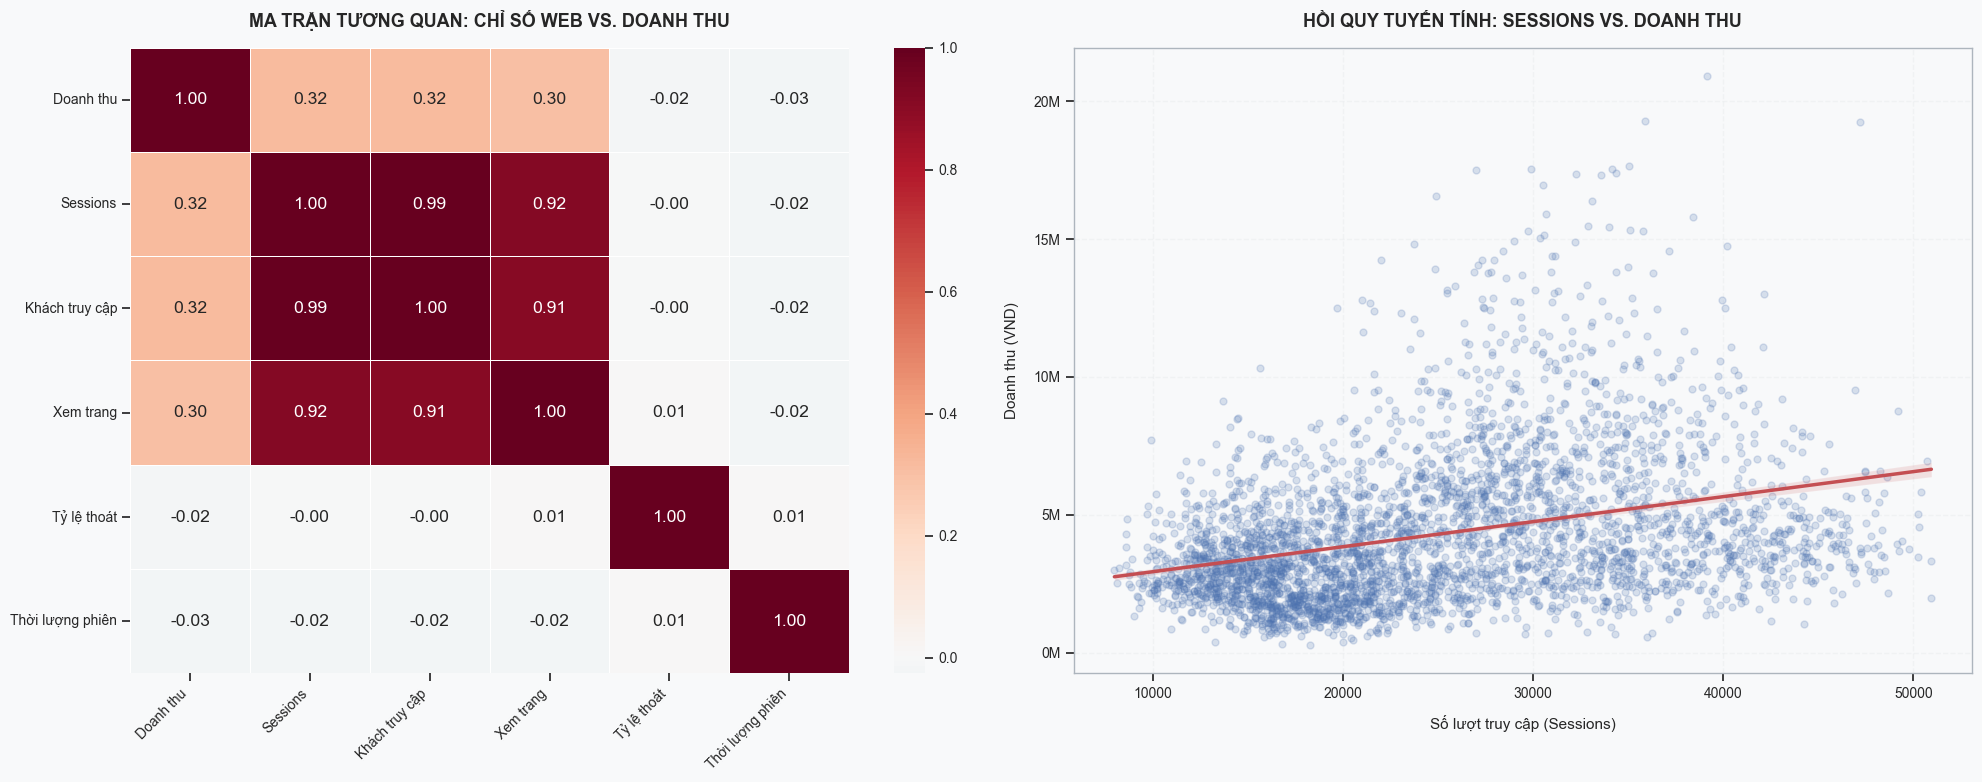

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# SUBPLOT 1 (Trái): Ma trận tương quan (Heatmap)
traffic_corr = sales_traffic[["Revenue", "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]].corr()

sns.heatmap(
    traffic_corr, 
    annot=True, 
    cmap="RdBu_r",
    center=0, 
    fmt=".2f", 
    ax=ax1,
    linewidths=0.5
)

ax1.set_title("MA TRẬN TƯƠNG QUAN: CHỈ SỐ WEB VS. DOANH THU", fontsize=13, fontweight="bold", pad=15)

labels = ["Doanh thu", "Sessions", "Khách truy cập", "Xem trang", "Tỷ lệ thoát", "Thời lượng phiên"]
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.set_yticklabels(labels, rotation=0)


# SUBPLOT 2 (Phải): Biểu đồ hồi quy (Regression Plot)
sns.regplot(
    data=sales_traffic, 
    x="sessions", 
    y="Revenue", 
    scatter_kws={"alpha": 0.2, "s": 25, "color": BLUE}, 
    line_kws={"linewidth": 2.5, "color": RED},
    ax=ax2
)

ax2.set_title("HỒI QUY TUYẾN TÍNH: SESSIONS VS. DOANH THU", fontsize=13, fontweight="bold", pad=15)
ax2.set_xlabel("Số lượt truy cập (Sessions)")
ax2.set_ylabel("Doanh thu (VND)")

ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'{x/1e6:,.0f}M'))

ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### 1. Các phát hiện chính

*   **Mối liên hệ thuận chiều ổn định:** Cả ma trận tương quan và biểu đồ hồi quy đều xác nhận doanh thu có mối tương quan dương với quy mô lưu lượng. Cụ thể, **Sessions** (Lượt truy cập) và **Khách truy cập** đều có hệ số tương quan **0.32** với doanh thu.

*   **Các chỉ số lưu lượng biến động cùng chiều:** Có sự tương quan cực kỳ chặt chẽ (từ **0.91 đến 0.99**) giữa Sessions, Khách truy cập và Xem trang. Điều này cho thấy khi website thu hút được thêm người dùng, họ có xu hướng duy trì hành vi duyệt web ổn định.

*   **Sự "độc lập" của các chỉ số chất lượng:** Một phát hiện đáng chú ý là **Tỷ lệ thoát** (-0.02) và **Thời lượng phiên** (-0.03) gần như không có sự tương quan trực tiếp với doanh thu trong tập dữ liệu này. Điều này gợi ý rằng việc khách hàng ở lại lâu hay thoát nhanh không quan trọng bằng việc họ có thực hiện hành vi mua hàng hay không.

*   **Biên độ dao động của doanh thu:** Biểu đồ hồi quy bên phải cho thấy dù đường xu hướng đi lên, nhưng các điểm dữ liệu phân tán khá rộng. Cùng một mức 30.000 sessions, doanh thu có thể dao động từ vài triệu đến gần 20 triệu VND. Điều này khẳng định lưu lượng mới chỉ là "điều kiện cần", còn tỷ lệ chuyển đổi (Conversion Rate) mới là "điều kiện đủ".

#### 2. Ý nghĩa kinh doanh và Đề xuất hành động

| Chỉ số tương quan | Mức độ | Ý nghĩa chiến lược |
| :--- | :--- | :--- |
| **Sessions vs. Doanh thu** | 0.32 | Tăng traffic giúp tăng doanh thu nhưng không phải là yếu tố duy nhất. |
| **Tỷ lệ thoát vs. Doanh thu** | -0.02 | Cải thiện UX/UI để giảm bounce rate có thể tốt cho thương hiệu nhưng chưa chắc kích cầu trực tiếp. |
| **Đường hồi quy** | Đi lên | Khẳng định mô hình kinh doanh đang tăng trưởng dựa trên quy mô lưu lượng. |

*   **Hành động chiến lược:**

    1.  **Tập trung vào Chất lượng Traffic:** Vì sự phân tán trên biểu đồ hồi quy rất lớn, doanh nghiệp nên tập trung vào việc thu hút đúng tệp khách hàng mục tiêu thay vì chỉ chạy đua theo số lượng Sessions đơn thuần.

    2.  **Tối ưu hóa Tỷ lệ Chuyển đổi (CRO):** Thay vì chỉ đầu tư ngân sách để đẩy đường hồi quy sang phải (tăng Sessions), hãy tập trung vào các yếu tố giúp đẩy các điểm dữ liệu lên cao hơn (tăng doanh thu trên mỗi lượt truy cập).
    
    3.  **Rà soát hành trình mua hàng:** Sự thiếu tương quan của "Thời lượng phiên" cho thấy khách hàng có thể đang mua sắm rất nhanh hoặc gặp khó khăn khiến họ thoát ra. Cần phân tích sâu hơn về phễu thanh toán để đảm bảo hành trình khách hàng ngắn gọn và hiệu quả nhất.

---

### 5.8. Hiệu suất Chuỗi cung ứng: Đứt hàng và Khả năng đáp ứng

Biểu đồ này cung cấp cái nhìn chi tiết về sức khỏe của chuỗi cung ứng trong hơn một thập kỷ qua. Việc đối chiếu giữa **Tỷ lệ đứt hàng** (Stockout rate) và **Tỷ lệ đáp ứng đơn hàng** (Fill rate) giúp doanh nghiệp đánh giá hiệu quả của việc quản trị kho hàng so với nhu cầu thực tế từ thị trường.

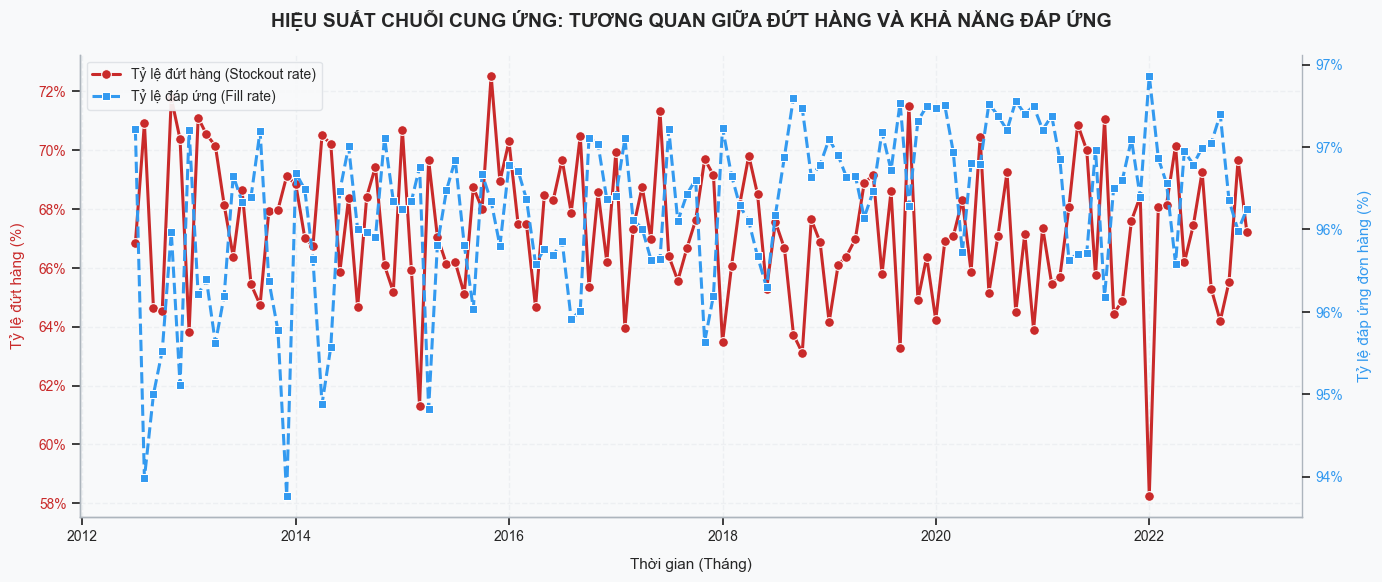

In [30]:
inventory_monthly = inventory.groupby(["year", "month"], as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    fill_rate=("fill_rate", "mean"),
    units_sold=("units_sold", "sum")
)
inventory_monthly["ym"] = pd.to_datetime(inventory_monthly["year"].astype(str) + "-" + inventory_monthly["month"].astype(str) + "-01")

fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=inventory_monthly,
    x="ym",
    y="stockout_rate",
    marker="o",
    markersize=7,
    ax=ax1,
    color=TWIN_ACCENT,
    linewidth=2.2,
    label="Tỷ lệ đứt hàng (Stockout rate)",
)

ax1.set_title("HIỆU SUẤT CHUỖI CUNG ỨNG: TƯƠNG QUAN GIỮA ĐỨT HÀNG VÀ KHẢ NĂNG ĐÁP ỨNG", 
             fontsize=14, fontweight="bold", pad=20)
ax1.set_xlabel("Thời gian (Tháng)")
ax1.set_ylabel("Tỷ lệ đứt hàng (%)", color=TWIN_ACCENT)
ax1.tick_params(axis='y', labelcolor=TWIN_ACCENT)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

ax2 = ax1.twinx()
sns.lineplot(
    data=inventory_monthly,
    x="ym",
    y="fill_rate",
    marker="s",
    markersize=6,
    ax=ax2,
    color=TWIN_FILL,
    linewidth=2.2,
    linestyle="--",
    label="Tỷ lệ đáp ứng (Fill rate)",
)

ax2.set_ylabel("Tỷ lệ đáp ứng đơn hàng (%)", color=TWIN_FILL)
ax2.tick_params(axis='y', labelcolor=TWIN_FILL)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.grid(False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
# Xóa legend mặc định của trục phụ nếu có
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
    
ax1.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True)

ax1.grid(True, linestyle="--", alpha=0.4)
sns.despine(ax=ax1, right=False)
sns.despine(ax=ax2, left=False)

plt.tight_layout()
plt.show()

#### 1. Các phát hiện chính

*   **Tương quan nghịch rõ rệt:** Về mặt tổng thể, hai chỉ số này có xu hướng biến động ngược chiều. Khi tỷ lệ đứt hàng tăng cao, tỷ lệ đáp ứng đơn hàng thường giảm xuống và ngược lại. Điều này phản ánh tính nhạy cảm của việc phục vụ khách hàng đối với mức độ sẵn sàng của hàng hóa.

*   **Biến động mạnh trong giai đoạn đầu (2012 - 2014):** Đây là thời kỳ chuỗi cung ứng gặp nhiều bất ổn nhất. Tỷ lệ đáp ứng đơn hàng có những cú sụt giảm sâu xuống dưới mức **94%** (đầu năm 2014), cho thấy sự gián đoạn nghiêm trọng trong khâu cung ứng hoặc dự báo nhu cầu sai lệch.

*   **Đỉnh điểm đứt hàng (Cuối 2015):** Tỷ lệ đứt hàng chạm mức kỷ lục (vượt **72%**). Tuy nhiên, sau giai đoạn này, doanh nghiệp dường như đã có những điều chỉnh về mặt vận hành để kiểm soát biến động tốt hơn.

*   **Sự ổn định dần từ năm 2019:** Trong giai đoạn gần đây (2019 - 2022), tỷ lệ đáp ứng đơn hàng duy trì khá ổn định ở mức cao (xấp xỉ **96.5% - 97%**). Điều này cho thấy hệ thống quản trị kho hàng đã trưởng thành và ổn định hơn.

*   **Sự sụt giảm bất thường đầu năm 2022:** Có một cú giảm cực sâu của tỷ lệ đứt hàng xuống mức dưới **58%**. Đây là một điểm dữ liệu đặc biệt cần điều tra thêm (có thể do nhập hàng quy mô lớn hoặc thay đổi cách tính toán chỉ số).

#### 2. Ý nghĩa kinh doanh và Đề xuất hành động

| Chỉ số | Trạng thái hiện tại | Ý nghĩa vận hành |
| :--- | :--- | :--- |
| **Tỷ lệ đáp ứng (Fill rate)** | ~97% (Tốt) | Khả năng phục vụ khách hàng đang ở mức cao. |
| **Tỷ lệ đứt hàng (Stockout rate)** | 64% - 70% (Cao) | Danh mục sản phẩm đang quá rộng hoặc quản lý tồn kho chưa tối ưu. |
| **Độ ổn định** | Cải thiện từ 2019 | Quy trình vận hành đã vào guồng quay bền vững. |

*   **Hành động chiến lược:**

    1.  **Tối ưu hóa Danh mục sản phẩm (SKU):** Mặc dù tỷ lệ đáp ứng đơn hàng cao, nhưng tỷ lệ đứt hàng duy trì ở mức 64% - 70% là một con số rất lớn. Điều này ám chỉ doanh nghiệp đang có quá nhiều mã hàng không cần thiết hoặc quản lý tồn kho dàn trải. Cần thực hiện phân tích ABC để tập trung nguồn lực vào nhóm hàng cốt lõi.

    2.  **Duy trì ngưỡng phục vụ 97%:** Đây là mức hiệu suất rất tốt để giữ chân khách hàng. Doanh nghiệp nên duy trì các tiêu chuẩn vận hành hiện tại để đảm bảo không bị tụt lại mức 94% như giai đoạn 2014.

    3.  **Hệ thống cảnh báo sớm:** Cần xây dựng các kịch bản dự phòng cho những đợt biến động mạnh (như đã xảy ra vào năm 2014 và 2015) để tránh việc sụt giảm khả năng đáp ứng đơn hàng một cách đột ngột.
    
    4.  **Kiểm tra tính chính xác của dữ liệu:** Làm rõ nguyên nhân cú giảm sâu vào đầu năm 2022 để xem đây là một cải tiến thực sự hay là một lỗi dữ liệu hệ thống.